# Parte 1: clasificación de sentimiento con ML clásico

**Curso:** Aprendizaje de Máquina 2026-20, Universidad de los Andes
**Grupo:** _TODO: nombre del grupo en Kaggle_
**Integrantes:** _TODO: nombres y códigos_

## Objetivo
Predecir el sentimiento **global** (`negativo`, `neutral`, `positivo`) de reseñas de productos en español. La métrica de Kaggle es **accuracy**.

## Restricciones de la Parte 1 (si se incumplen, la nota es 0)
- Solo clasificadores de **scikit-learn**.
- Nada de redes neuronales, transformers ni embeddings preentrenados.
- Representación del texto: bolsa de palabras, TF-IDF, n-gramas.
- Resultados **replicables** a partir de este notebook y del modelo guardado con `joblib`.

## Estructura del notebook
1. Configuración
2. Carga de datos
3. Análisis exploratorio y corrección de los datos
4. Partición de los datos y esquema de validación
5. Representación del texto y modelos base
6. Más allá de los n-gramas: dónde está la opinión
7. Ajuste de hiperparámetros
8. Evaluación y análisis de errores
9. Modelo final
10. Bitácora de envíos y conclusiones
11. Declaración de uso de IA generativa

## 1. Configuración

In [1]:
import os

# Un solo hilo en las librerías numéricas, ANTES de importar numpy/sklearn: el clasificador de segmentos de la
# iteración 13 (liblinear) da resultados ligeramente distintos según el número de hilos. Con 1 hilo, el modelo
# es el mismo en cualquier computador.
for variable in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ[variable] = "1"

import re
import time
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier, StackingClassifier, VotingClassifier)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_val_score, cross_validate, train_test_split)
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

SEED = 42  # usar en todo lo que tenga azar para que el resultado sea replicable
np.random.seed(SEED)

DATA_DIR = Path("data")
SUB_DIR = Path("submissions")  # archivos de envío a Kaggle
MODEL_DIR = Path("models")     # modelo final guardado con joblib
SUB_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

LABELS = ["negativo", "neutral", "positivo"]

print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)
if sklearn.__version__ != "1.9.1":
    print("OJO: requirements.txt fija scikit-learn 1.9.1. Con otra versión el modelo guardado puede cambiar.")

scikit-learn 1.9.1 | pandas 3.0.6


## 2. Carga de datos

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")  # SOLO para predecir al final, nunca para entrenar ni ajustar

X, y = train["text"], train["label"]
print(train.shape, eval_df.shape)
train.head()

(12000, 3) (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


## 3. Análisis exploratorio

En esta sección solo se **observan** los datos para saber qué hay. No se limpia ni se modifica nada: `train` y `eval_df` quedan intactos.

### 3.1 Estructura y calidad básica
¿Cuántas filas y columnas hay, de qué tipo son, hay nulos, textos vacíos o repetidos?

In [3]:
for nombre, df in [("train", train), ("eval", eval_df)]:
    print(f"--- {nombre}: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(df.dtypes.to_string())
    print("Nulos por columna:", df.isna().sum().to_dict())
    print("Textos vacíos:", (df["text"].str.strip() == "").sum())
    print("Ids repetidos:", df["id"].duplicated().sum(), "| Textos repetidos:", df["text"].duplicated().sum())
    print()

print("Textos de eval que también aparecen en train:", eval_df["text"].isin(train["text"]).sum())

--- train: 12000 filas, 3 columnas
id       int64
text       str
label      str
Nulos por columna: {'id': 0, 'text': 0, 'label': 0}
Textos vacíos: 0
Ids repetidos: 0 | Textos repetidos: 0

--- eval: 3000 filas, 2 columnas
id      int64
text      str
Nulos por columna: {'id': 0, 'text': 0}
Textos vacíos: 0
Ids repetidos: 0 | Textos repetidos: 0

Textos de eval que también aparecen en train: 0


### 3.2 Distribución de clases
¿Qué valores toma `label` y qué tan balanceadas están las clases? Sirve para saber qué accuracy tendría un modelo que siempre predice la clase más frecuente.

Valores distintos de label: ['negativo', 'neutral', 'positivo']


,reseñas,porcentaje
label,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


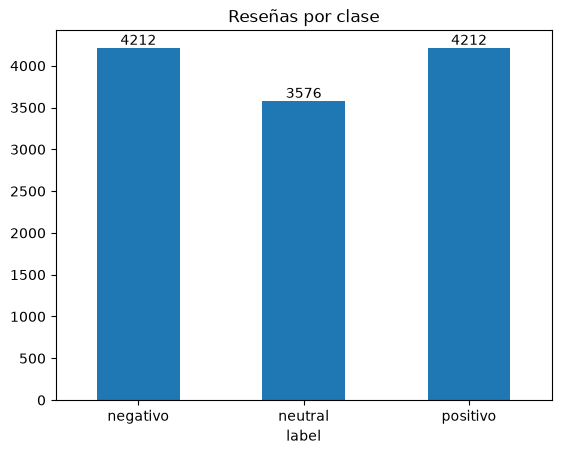

Accuracy de predecir siempre la clase más frecuente: 0.351


In [4]:
conteo = y.value_counts()
resumen_clases = pd.DataFrame({"reseñas": conteo, "porcentaje": (conteo / len(y) * 100).round(1)})
print("Valores distintos de label:", sorted(y.unique()))
display(resumen_clases)

ax = conteo.reindex(LABELS).plot.bar(rot=0, title="Reseñas por clase")
ax.bar_label(ax.containers[0])
plt.show()

print("Accuracy de predecir siempre la clase más frecuente:", round(conteo.max() / len(y), 3))

### 3.3 Longitud de las reseñas
¿Qué tan largas son (caracteres, palabras, oraciones)? ¿Cambia la longitud según la clase? ¿Se parecen `train` y `eval`?

Longitud en train (todas las clases):


,caracteres,palabras,oraciones
count,12000.0,12000.0,12000.0
mean,281.4,53.9,3.9
std,69.2,13.2,0.8
min,14.0,3.0,1.0
25%,245.0,47.0,4.0
50%,280.0,54.0,4.0
75%,320.0,61.0,4.0
max,579.0,110.0,7.0


Promedios por clase:


,caracteres,palabras,oraciones
label,,,
negativo,283.7,54.2,3.8
neutral,271.0,52.3,3.9
positivo,287.9,55.0,3.9


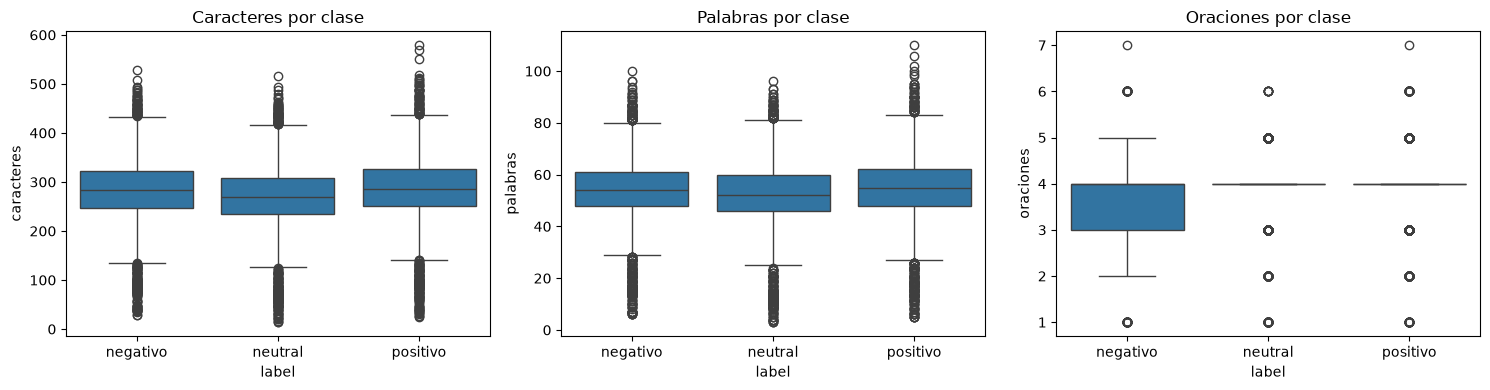

Promedios train vs. eval:


,train,eval
caracteres,281.4,282.5
palabras,53.9,54.2
oraciones,3.9,3.9


In [5]:
def medidas(textos):
    """Tabla con la longitud de cada texto. No modifica los datos originales."""
    return pd.DataFrame({
        "caracteres": textos.str.len(),
        "palabras": textos.str.split().str.len(),
        "oraciones": textos.str.count(r"[.!?]+"),
    })

largos = medidas(X).assign(label=y)
print("Longitud en train (todas las clases):")
display(largos.describe().round(1))
print("Promedios por clase:")
display(largos.groupby("label").mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["caracteres", "palabras", "oraciones"]):
    sns.boxplot(data=largos, x="label", y=col, order=LABELS, ax=ax)
    ax.set_title(f"{col.capitalize()} por clase")
plt.tight_layout(); plt.show()

print("Promedios train vs. eval:")
display(pd.DataFrame({"train": medidas(X).mean(), "eval": medidas(eval_df["text"]).mean()}).round(1))

### 3.4 Leer ejemplos
Leer reseñas reales de cada clase es la parte más importante del EDA: aquí se ve cómo están escritas y qué las hace positivas, negativas o neutrales.

In [6]:
for label in LABELS:
    print(f"===== {label}")
    for t in train.loc[y == label, "text"].sample(5, random_state=SEED):
        print("-", t)
    print()

===== negativo
- La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.
- Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora.
- Llevo ya un rato con él, lo compré para usar en la cocina de mi casa y llegó en tres días. En mi opinión el material quedó sólido en general, se siente firme al tocarlo. La duración de la carga terminó siendo mal hecha desde el primer día, y eso que seguí las instrucciones de uso.
- Se lo compré a un familiar hace unos meses, fue regalo de cumpleaños. El envío llegó en tiempo, sin problema, y el paquete venía bien cerrado. La terminación terminó siendo 

In [7]:
# Las reseñas más cortas y las más largas
orden = largos["palabras"].sort_values()
for titulo, idx in [("MÁS CORTAS", orden.index[:5]), ("MÁS LARGAS", orden.index[-3:])]:
    print(f"===== {titulo}")
    for i in idx:
        print(f"[{y[i]} | {largos.loc[i, 'palabras']} palabras] {X[i]}")
    print()

===== MÁS CORTAS
[neutral | 3 palabras] Viene en beige.
[neutral | 3 palabras] Viene en azul.
[neutral | 3 palabras] Viene en dorado.
[neutral | 4 palabras] Trae adhesivs de regalo.
[neutral | 4 palabras] Llego en tres diass.

===== MÁS LARGAS
[positivo | 102 palabras] Me llegó el procesador el jueves por la mañana acá en casa, lo compré la semana pasada y lo trajo la mensajería de siempre. La caja venía cerrada de fábrica, con el manual y los cables aparte en una bolsita. Lo instalé ese mismo día en el escritorio mientras escuchaba música, sin ningún apuro. Por cierto, el soporte técnico se sintió pésimo a decir verdad, anduve preguntando por el chat unas dudas que tuve. En fin, que después de armarlo todo el procesador terminó siendo bien construido para ser honesto, lo dejé corriendo toda la noche y se portó como se esperaba.
[positivo | 106 palabras] Me llego el telefono un martes por la tarde, como tres dias despues de haberlo pedido, y venia en su caja sellada con el cable y el c

### 3.5 Caracteres y ruido en el texto
¿Qué tipo de caracteres aparecen? Tildes, mayúsculas, números, signos, emojis, enlaces. Esto muestra qué habría que normalizar más adelante (aquí solo se mide, no se corrige).

In [8]:
patrones = {
    "con tildes o ñ": r"[áéíóúüñÁÉÍÓÚÜÑ]",
    "con números": r"\d",
    "con signos ¡ o ¿": r"[¡¿]",
    "con signos ! o ?": r"[!?]",
    "con palabras en MAYÚSCULAS": r"\b[A-ZÁÉÍÓÚÑ]{3,}\b",
    "con enlaces o @": r"https?://|www\.|@",
    "con caracteres fuera del español": r"[^\x00-\x7FáéíóúüñÁÉÍÓÚÜÑ¡¿]",
}
ruido = pd.DataFrame({
    nombre: {
        "train (%)": X.str.contains(p).mean() * 100,
        **{f"{l} (%)": X[y == l].str.contains(p).mean() * 100 for l in LABELS},
        "eval (%)": eval_df["text"].str.contains(p).mean() * 100,
    }
    for nombre, p in patrones.items()
}).T.round(1)
print("Porcentaje de reseñas que contienen cada tipo de carácter:")
display(ruido)

# Inventario de caracteres que no son letras, números ni espacios
from collections import Counter
simbolos = Counter(c for t in X for c in t if not c.isalnum() and not c.isspace())
print("Símbolos presentes en train:", dict(simbolos.most_common()))

Porcentaje de reseñas que contienen cada tipo de carácter:


,train (%),negativo (%),neutral (%),positivo (%),eval (%)
con tildes o ñ,68.7,68.8,67.0,70.1,68.6
con números,9.4,4.8,20.2,4.8,8.0
con signos ¡ o ¿,0.0,0.0,0.1,0.0,0.0
con signos ! o ?,0.0,0.0,0.0,0.0,0.0
con palabras en MAYÚSCULAS,6.2,3.2,12.7,3.7,6.1
con enlaces o @,0.0,0.0,0.0,0.0,0.0
con caracteres fuera del español,0.0,0.0,0.1,0.0,0.0


Símbolos presentes en train: {'.': 46713, ',': 34166, '-': 450, ':': 302, ';': 144, '\xad': 16, '¡': 4, '±': 3, '©': 3, "'": 2, '%': 1}


### 3.6 Vocabulario
¿Cuántas palabras distintas hay, cuáles son las más frecuentes y cuáles aparecen mucho más en una clase que en las otras? ¿Qué tanto vocabulario de `eval` no está en `train`?

In [9]:
# Solo se cuenta para explorar: en minúsculas, sin quitar tildes ni stopwords
contador = CountVectorizer(lowercase=True, binary=True)  # binary=True: cuenta en cuántas reseñas aparece cada palabra
M = contador.fit_transform(X)
palabras = contador.get_feature_names_out()
print("Palabras distintas en train:", len(palabras))

# Porcentaje de reseñas de cada clase que contienen cada palabra
frec = pd.DataFrame({l: np.asarray(M[(y == l).values].mean(axis=0)).ravel() * 100 for l in LABELS}, index=palabras)
frec["todas"] = np.asarray(M.mean(axis=0)).ravel() * 100

print("\nPalabras más frecuentes (% de reseñas que las contienen):")
display(frec.sort_values("todas", ascending=False).head(20).round(1))

for l in LABELS:
    otras = [o for o in LABELS if o != l]
    diferencia = frec[l] - frec[otras].max(axis=1)
    print(f"\nPalabras mucho más frecuentes en '{l}' que en las otras clases:")
    display(frec.loc[diferencia.sort_values(ascending=False).head(15).index, LABELS].round(1))

vocab_eval = set(CountVectorizer(lowercase=True).fit(eval_df["text"]).get_feature_names_out())
nuevas = vocab_eval - set(palabras)
print(f"\nPalabras de eval que no están en train: {len(nuevas)} de {len(vocab_eval)} ({len(nuevas) / len(vocab_eval):.1%})")
print("Ejemplos:", sorted(nuevas)[:30])

Palabras distintas en train: 6035

Palabras más frecuentes (% de reseñas que las contienen):


,negativo,neutral,positivo,todas
en,93.8,95.0,94.3,94.3
la,96.0,90.4,95.9,94.3
de,90.9,89.4,90.3,90.2
lo,90.0,90.6,87.7,89.4
el,89.8,86.8,89.3,88.7
que,69.8,72.5,68.1,70.0
me,72.2,52.7,73.7,66.9
un,56.3,66.2,56.5,59.4
llegó,55.4,57.1,57.8,56.8
por,48.8,63.8,49.6,53.5



Palabras mucho más frecuentes en 'negativo' que en las otras clases:


,negativo,neutral,positivo
pero,9.5,3.7,3.8
eso,27.4,11.3,23.1
sí,16.1,1.7,13.0
unos,26.8,22.8,24.0
muy,10.8,0.2,8.2
es,20.3,18.1,17.4
cuesta,6.9,0.0,4.8
cuatro,28.6,24.2,26.7
hace,36.7,34.8,34.0
mal,7.3,0.7,5.7



Palabras mucho más frecuentes en 'neutral' que en las otras clases:


,negativo,neutral,positivo
caja,21.2,44.8,20.6
paquete,6.3,27.5,6.0
trae,5.1,25.6,4.7
viene,3.3,23.0,3.1
por,48.8,63.8,49.6
no,27.1,40.6,25.9
color,4.2,16.9,3.8
dos,12.0,24.2,11.8
unidades,2.4,14.3,2.3
voltios,2.3,13.1,2.1



Palabras mucho más frecuentes en 'positivo' que en las otras clases:


,negativo,neutral,positivo
mi,40.6,29.9,46.9
uso,54.2,26.0,59.3
casa,44.7,47.6,52.1
aun,7.5,0.6,11.1
casi,23.6,10.5,26.9
verdad,39.5,2.3,41.7
después,13.9,7.4,16.1
tres,36.1,36.0,38.3
sobre,7.7,6.7,9.9
tardes,8.5,3.5,10.6



Palabras de eval que no están en train: 564 de 3481 (16.2%)
Ejemplos: ['540', '60', '800', 'abrri', 'acaban', 'acampar', 'accierto', 'aceite', 'acomodarle', 'acondicioné', 'acondicé', 'aconsejar', 'actividades', 'actualizacion', 'adaptacion', 'afectará', 'afloja', 'aflojando', 'agarraron', 'agencia', 'agregaar', 'agregado', 'agregarle', 'aguantara', 'ajustan', 'ajustarle', 'alargarme', 'alcancó', 'alcanzara', 'almorzamos']


**Conclusiones del EDA** _(TODO: completar con lo que observen)_
- Balance de clases: ...
- Estructura típica de una reseña (relleno, opinión, conector, opinión final): ...
- Los conectores aparecen casi igual en positivas y negativas, así que lo que importa es **qué viene después**: ...
- Ruido (reseñas sin tildes, errores de tipeo): ...

**Hipótesis:** el sentimiento global lo determina la última cláusula de opinión. Se pone a prueba en la sección 6.

### 3.7 Corrección de los datos
Con lo que mostró el EDA se corrige **solo** lo que de verdad aparece en los datos. Los textos originales no se tocan: el resultado queda en una columna nueva, `text_limpio`.

| Hallazgo del EDA | Corrección |
|---|---|
| El 31 % de las reseñas no tiene tildes ni ñ ("llego", "tamano") y el resto sí | Quitar tildes y ñ en todas, para que "llegó" y "llego" sean la misma palabra |
| Hay mayúsculas al inicio de oración y en siglas ("USB", "AAA") | Pasar todo a minúsculas |
| 3 reseñas de `train` tienen la codificación dañada ("reseÃ±a", "llegA3") | Reparar esos pares de caracteres ("reseña", "llegó") |
| 1 reseña más tiene un guion invisible (`\xad`) suelto en medio de una palabra | Eliminarlo |

**Lo que no se corrige, y por qué:**
- **Filas:** no se elimina ninguna, porque no hay nulos, textos vacíos ni repetidos.
- **Etiquetas:** solo existen los tres valores esperados.
- **Palabras vacías ("no", "pero", "aun así"):** se conservan, porque cambian el sentido de la opinión.
- **Puntuación:** se conserva, porque marca dónde termina cada oración.
- **Números:** se conservan; aparecen sobre todo en las reseñas neutrales, así que ayudan a distinguirlas.
- **Errores de tipeo ("trs dias", "autonoia"):** no se corrigen, porque no hay una regla segura para adivinar la palabra correcta.

La corrección es una regla fija (no aprende nada de los datos), así que aplicarla también a `eval` no usa `eval` para entrenar.

In [10]:
# Pares que deja una codificación dañada (UTF-8 leído como Latin-1) -> letra correcta
MOJIBAKE = {"Ã¡": "á", "Ã©": "é", "Ã\xad": "í", "Ã³": "ó", "Ãº": "ú", "Ã±": "ñ"}
# Variante en la que además la Ã perdió su tilde: "llegA3" -> "llegó"
MOJIBAKE_DEGRADADO = {"A¡": "á", "A©": "é", "A\xad": "í", "A3": "ó", "A³": "ó", "Aº": "ú", "A±": "ñ"}
PATRON_DEGRADADO = re.compile(r"(?<=[a-zñ])A[¡©\xad3³º±]")  # solo dentro de una palabra, para no tocar "AA" o "AAA"

def reparar_par(coincidencia):
    return MOJIBAKE_DEGRADADO[coincidencia.group()]

def corregir_texto(texto):
    """Devuelve una copia corregida del texto. No modifica el original."""
    for malo, bueno in MOJIBAKE.items():                 # 1. reparar la codificación dañada
        texto = texto.replace(malo, bueno)
    texto = PATRON_DEGRADADO.sub(reparar_par, texto)
    texto = texto.replace("\xad", "")                    # 2. quitar guiones invisibles
    texto = texto.lower()                                # 3. minúsculas
    texto = unicodedata.normalize("NFKD", texto)         # 4. quitar tildes y ñ
    return "".join(c for c in texto if not unicodedata.combining(c))

train["text_limpio"] = train["text"].map(corregir_texto)
eval_df["text_limpio"] = eval_df["text"].map(corregir_texto)

print("Filas en train:", len(train), "| en eval:", len(eval_df), "(no se eliminó ninguna)")
train[["text", "text_limpio", "label"]].head(3)

Filas en train: 12000 | en eval: 3000 (no se eliminó ninguna)


,text,text_limpio,label
0,Lo pedí un martes por la noche y me llegó al d...,lo pedi un martes por la noche y me llego al d...,neutral
1,Se lo compré a un familiar después de pensarla...,se lo compre a un familiar despues de pensarla...,positivo
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedi a mediados de mes y me llego en tres d...,negativo


**Comprobación.** Las mismas medidas del EDA, antes y después de corregir, y ejemplos de cómo cambia el texto.

In [11]:
PATRON_DANADO = r"Ã|(?<=[a-zñ])A[¡©\xad3³º±]|\xad"

def resumen(textos):
    return {
        "reseñas con tildes o ñ": textos.str.contains(r"[áéíóúüñÁÉÍÓÚÜÑ]").sum(),
        "reseñas con mayúsculas": textos.str.contains(r"[A-ZÁÉÍÓÚÑ]").sum(),
        "reseñas con codificación dañada o guion invisible": textos.str.contains(PATRON_DANADO).sum(),
        "palabras distintas": len(CountVectorizer().fit(textos).vocabulary_),
        "textos repetidos": textos.duplicated().sum(),
        "textos vacíos": (textos.str.strip() == "").sum(),
    }

display(pd.DataFrame({
    "train antes": resumen(train["text"]),
    "train después": resumen(train["text_limpio"]),
    "eval antes": resumen(eval_df["text"]),
    "eval después": resumen(eval_df["text_limpio"]),
}))

# Todos los caracteres distintos que quedan después de corregir
print("Caracteres que quedan en train:", "".join(sorted(set("".join(train["text_limpio"])))))
print("Caracteres que quedan en eval: ", "".join(sorted(set("".join(eval_df["text_limpio"])))))

# Palabras de eval que no están en train, antes y después
for col in ["text", "text_limpio"]:
    vocab_train = set(CountVectorizer().fit(train[col]).vocabulary_)
    vocab_eval = set(CountVectorizer().fit(eval_df[col]).vocabulary_)
    nuevas = vocab_eval - vocab_train
    print(f"{col}: {len(nuevas)} de {len(vocab_eval)} palabras de eval no están en train ({len(nuevas) / len(vocab_eval):.1%})")

# Ejemplos: una reseña normal y las que tenían la codificación dañada
danadas = train.index[train["text"].str.contains(PATRON_DANADO)]
for i in [0, *danadas]:
    print(f"\n[{i}] ANTES:   {train.loc[i, 'text'][:160]}")
    print(f"[{i}] DESPUÉS: {train.loc[i, 'text_limpio'][:160]}")

,train antes,train después,eval antes,eval después
reseñas con tildes o ñ,8242,0,2058,0
reseñas con mayúsculas,12000,0,3000,0
reseñas con codificación dañada o guion invisible,4,0,0,0
palabras distintas,6035,5455,3481,3143
textos repetidos,0,0,0,0
textos vacíos,0,0,0,0


Caracteres que quedan en train:  %',-.0123456789:;abcdefghijklmnopqrstuvwxyz
Caracteres que quedan en eval:   ,-.0123456789:;abcdefghijklmnopqrstuvwxyz
text: 564 de 3481 palabras de eval no están en train (16.2%)
text_limpio: 521 de 3143 palabras de eval no están en train (16.6%)

[0] ANTES:   Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo 
[0] DESPUÉS: lo pedi un martes por la noche y me llego al dia siguiente. es el modelo en color negro, el basico de la linea. lo pese en la bascula de la cocina y marca algo 

[716] ANTES:   Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por la tarde, unos tres dÃ­as despuÃ©s de la compra. El color es rojo, tal cual se veÃ
[716] DESPUÉS: pues aqui va lo prometido, mi resena del articulo. me llego el martes por la tarde, unos tres dias despues de la compra. el color es rojo, tal cual se veia en l

[3438] ANTES:   

## 4. Partición de los datos y esquema de validación
`eval.csv` no tiene etiquetas, así que no sirve para medir el modelo. Hay que construir la evaluación con `train.csv`.

### 4.1 Conjunto de prueba propio
> **Qué hacer aquí:** apartar una parte de `train.csv` (por ejemplo el 20 %) como prueba, de forma estratificada y con la semilla fija. Ese conjunto no se vuelve a tocar hasta la sección 9.

In [12]:
X = train["text"]      
y = train["label"]

X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Entrenamiento : {len(X_ent):>6} reseñas  ({len(X_ent)/len(train):.0%})")
print(f"Prueba        : {len(X_prueba):>6} reseñas  ({len(X_prueba)/len(train):.0%})")
print(f"Total         : {len(train):>6} reseñas\n")

proporciones = pd.DataFrame({
    "train.csv completo": y.value_counts(normalize=True),
    "entrenamiento": y_ent.value_counts(normalize=True),
    "prueba": y_prueba.value_counts(normalize=True),
}).reindex(LABELS).mul(100).round(2)
proporciones["conteo en prueba"] = y_prueba.value_counts().reindex(LABELS)

for p in [0.75, 0.90]:
    error = np.sqrt(p * (1 - p) / len(X_prueba))
    print(f"Si la accuracy real es {p:.2f}, la prueba la mide con un error estándar de ±{error * 100:.1f} puntos")
    

proporciones

Entrenamiento :   9600 reseñas  (80%)
Prueba        :   2400 reseñas  (20%)
Total         :  12000 reseñas

Si la accuracy real es 0.75, la prueba la mide con un error estándar de ±0.9 puntos
Si la accuracy real es 0.90, la prueba la mide con un error estándar de ±0.6 puntos


,train.csv completo,entrenamiento,prueba,conteo en prueba
label,,,,
negativo,35.1,35.09,35.12,843
neutral,29.8,29.80,29.79,715
positivo,35.1,35.10,35.08,842


**Decisión.**
- **20 % (2.400 reseñas) como prueba.** Con 2.400 reseñas el error estándar de la accuracy es de ±0,9 puntos si el modelo acierta el 75 % y de ±0,6 puntos si acierta el 90 %: suficiente para confirmar el resultado final. A cambio quedan 9.600 reseñas para entrenar y validar.
- **Estratificada:** las tres clases conservan su proporción original (35,1 / 29,8 / 35,1 %) en las dos partes, como muestra la tabla. Sin estratificar, el azar podría dejar la prueba con más o menos neutrales, que son las más fáciles, y su accuracy no sería comparable.
- **Semilla fija:** con `SEED = 42` la partición es siempre la misma. Es la misma partición de los notebooks de `notebooks_iteraciones/`, así que los números de este notebook y los de cada iteración son comparables.

### 4.2 Validación cruzada dentro de entrenamiento
Para comparar modelos y elegir hiperparámetros se usa validación cruzada estratificada de **5 pliegues**, solo sobre las 9.600 reseñas de entrenamiento. La función `evaluar` corre la validación cruzada de cualquier pipeline y guarda el resultado en la tabla `experimentos` (accuracy media, desviación entre pliegues, F1 macro y tiempo).

Todo lo que aprende de los datos (vocabulario, pesos IDF, palabras de opinión) va **dentro de un `Pipeline`**: en cada pliegue se ajusta solo con la parte de entrenamiento de ese pliegue, y el pliegue de validación es de verdad texto que el modelo no vio.

In [13]:
# 4.2 Validación cruzada estratificada de 5 pliegues, solo sobre las 9.600 reseñas de entrenamiento
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

experimentos = []  # tabla de experimentos: una fila por modelo evaluado


def evaluar(nombre, modelo, seccion, **detalles):
    """Valida un pipeline con los 5 pliegues de CV, guarda el resultado en `experimentos` y lo devuelve."""
    inicio = time.perf_counter()
    res = cross_validate(modelo, X_ent, y_ent, cv=CV, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    fila = {"sección": seccion, "experimento": nombre, **detalles,
            "accuracy": res["test_accuracy"].mean(), "desv. accuracy": res["test_accuracy"].std(),
            "F1 macro": res["test_f1_macro"].mean(), "segundos": time.perf_counter() - inicio}
    experimentos[:] = [f for f in experimentos if f["experimento"] != nombre]  # si se re-ejecuta, se reemplaza
    experimentos.append(fila)
    print(f"{nombre:<55} accuracy {fila['accuracy']:.4f} ± {fila['desv. accuracy']:.4f}"
          f" | F1 macro {fila['F1 macro']:.4f} | pliegues {np.round(res['test_accuracy'], 3)}")
    return fila


def tabla(seccion):
    """Experimentos de una sección, ordenados de mejor a peor."""
    filas = pd.DataFrame([f for f in experimentos if f["sección"] == seccion]).drop(columns="sección")
    return filas.sort_values("accuracy", ascending=False).round(4).reset_index(drop=True)


# Vectorizadores que aplican la corrección de 3.7 a cada reseña antes de tokenizar
def bolsa(**parametros):
    return CountVectorizer(preprocessor=corregir_texto, **parametros)


def tfidf(**parametros):
    return TfidfVectorizer(preprocessor=corregir_texto, **parametros)


def regresion_logistica(C=1.0):
    return LogisticRegression(C=C, max_iter=3000)


# Comprobación: cada pliegue de validación conserva la proporción de clases
pliegues = pd.DataFrame({
    f"pliegue {k + 1}": y_ent.iloc[idx_val].value_counts(normalize=True).reindex(LABELS) * 100
    for k, (_, idx_val) in enumerate(CV.split(X_ent, y_ent))
}).round(1)
print("Proporción de clases (%) en la parte de validación de cada pliegue:")
display(pliegues)
print(f"Cada pliegue entrena con {len(X_ent) * 4 // 5} reseñas y valida con {len(X_ent) // 5}.")

Proporción de clases (%) en la parte de validación de cada pliegue:


,pliegue 1,pliegue 2,pliegue 3,pliegue 4,pliegue 5
label,,,,,
negativo,35.1,35.1,35.1,35.1,35.1
neutral,29.8,29.8,29.8,29.8,29.8
positivo,35.1,35.1,35.1,35.1,35.1


Cada pliegue entrena con 7680 reseñas y valida con 1920.


**Decisión.**
- **5 pliegues:** cada modelo se entrena con 7.680 reseñas y se valida con 1.920, y se obtienen 5 medidas para ver cuánto varía el resultado (columna `desv. accuracy`). Con 10 pliegues cada experimento tardaría el doble sin cambiar las conclusiones.
- **Estratificada:** cada pliegue conserva la proporción de clases (tabla de arriba), así ningún pliegue queda con más neutrales que otro por azar.
- **Diferencias pequeñas:** la desviación entre pliegues ronda ±1 punto, así que una diferencia menor a un punto entre dos modelos no se considera real; en ese caso se prefiere el modelo más simple.
- **El modelo no se elige mirando la prueba ni el leaderboard:** si se probaran muchos modelos contra la prueba y se escogiera el mejor, la prueba dejaría de medir con honestidad (el modelo se estaría ajustando a ella). Lo mismo pasa con el score público de Kaggle, que además es solo una parte de `eval.csv`: el ranking final lo decide el score privado. Por eso todas las decisiones se toman con validación cruzada, y la prueba se usa una sola vez, en la sección 9.
- **Funciones auxiliares:** `bolsa()` y `tfidf()` crean vectorizadores que ya traen `corregir_texto` como `preprocessor`, y `regresion_logistica()` fija `max_iter=3000` para que la optimización siempre converja.

## 5. Representación del texto y modelos base
En esta sección se recorre el camino visto en clase: de la representación más simple a la más completa, midiendo cada cambio con la validación cruzada de la sección 4. Aquí están las iteraciones 01 a 05 enviadas a Kaggle, todas con el texto completo de la reseña. El orden y la fecha de cada envío están en la bitácora de la sección 10.

### 5.1 Línea base trivial
Un clasificador que siempre predice la clase más frecuente. Todo lo demás se compara contra ese número.

In [14]:
evaluar("Clase más frecuente (DummyClassifier)", DummyClassifier(strategy="most_frequent"), "5.1")
tabla("5.1")

Clase más frecuente (DummyClassifier)                   accuracy 0.3509 ± 0.0002 | F1 macro 0.1732 | pliegues [0.351 0.351 0.351 0.351 0.351]


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Clase más frecuente (DummyClassifier),0.3509,0.0002,0.1732,2.9198


### 5.2 Bolsa de palabras contra TF-IDF
El mismo clasificador (regresión logística) con cuatro representaciones: conteos, presencia/ausencia (binaria), TF-IDF y TF-IDF con frecuencia sublineal (`1 + log(tf)`).

La regularización interactúa con la escala de las variables: TF-IDF normaliza cada reseña a norma 1, así que sus valores son mucho más pequeños que los conteos y el mismo `C` regulariza mucho más. Para que la comparación sea justa, cada representación se prueba con varios valores de `C` (en `LogisticRegression`, **bajar `C` es regularizar más**).

Después se prueba `min_df`, que descarta las palabras que aparecen en menos de `min_df` reseñas (errores de tipeo, palabras raras que no generalizan). Al final se miden con la misma validación cruzada las iteraciones 01 y 02 enviadas a Kaggle.

In [15]:
representaciones = {
    "bolsa de palabras (conteos)": bolsa(),
    "bolsa de palabras (binaria)": bolsa(binary=True),
    "TF-IDF": tfidf(),
    "TF-IDF sublineal": tfidf(sublinear_tf=True),
}
for nombre, vectorizador in representaciones.items():
    for C in [0.3, 1, 3, 10]:
        modelo = Pipeline([("vec", clone(vectorizador)), ("clf", regresion_logistica(C))])
        evaluar(f"{nombre} + LR (C={C})", modelo, "5.2", representación=nombre, C=C)

print("\nAccuracy por representación (filas) y valor de C (columnas):")
display(tabla("5.2").pivot(index="representación", columns="C", values="accuracy"))

for min_df in [1, 2, 5]:
    vectorizador = tfidf(sublinear_tf=True, min_df=min_df)
    n_terminos = len(clone(vectorizador).fit(X_ent).vocabulary_)
    evaluar(f"TF-IDF sublineal (min_df={min_df}) + LR (C=10)",
            Pipeline([("vec", vectorizador), ("clf", regresion_logistica(10))]), "5.2b",
            min_df=min_df, términos=n_terminos)
display(tabla("5.2b"))

evaluar("iter01: bolsa de palabras + Naive Bayes", Pipeline([("vec", bolsa()), ("clf", MultinomialNB())]), "envíos")
evaluar("iter02: TF-IDF + LR por defecto", Pipeline([("vec", tfidf()), ("clf", regresion_logistica())]), "envíos")
display(tabla("envíos"))

bolsa de palabras (conteos) + LR (C=0.3)                accuracy 0.7368 ± 0.0088 | F1 macro 0.7479 | pliegues [0.742 0.735 0.74  0.746 0.721]
bolsa de palabras (conteos) + LR (C=1)                  accuracy 0.7368 ± 0.0064 | F1 macro 0.7484 | pliegues [0.741 0.734 0.74  0.743 0.726]
bolsa de palabras (conteos) + LR (C=3)                  accuracy 0.7356 ± 0.0105 | F1 macro 0.7477 | pliegues [0.748 0.728 0.734 0.747 0.721]
bolsa de palabras (conteos) + LR (C=10)                 accuracy 0.7249 ± 0.0113 | F1 macro 0.7377 | pliegues [0.74  0.713 0.723 0.736 0.712]
bolsa de palabras (binaria) + LR (C=0.3)                accuracy 0.7364 ± 0.0103 | F1 macro 0.7474 | pliegues [0.748 0.735 0.736 0.744 0.718]
bolsa de palabras (binaria) + LR (C=1)                  accuracy 0.7369 ± 0.0097 | F1 macro 0.7484 | pliegues [0.739 0.731 0.744 0.749 0.722]
bolsa de palabras (binaria) + LR (C=3)                  accuracy 0.7320 ± 0.0062 | F1 macro 0.7440 | pliegues [0.737 0.728 0.732 0.74  0.723]
bolsa 

C,0.3,1.0,3.0,10.0
representación,,,,
TF-IDF,0.7109,0.7252,0.7341,0.7366
TF-IDF sublineal,0.7162,0.7279,0.7351,0.7356
bolsa de palabras (binaria),0.7364,0.7369,0.7320,0.7263
bolsa de palabras (conteos),0.7368,0.7368,0.7356,0.7249


TF-IDF sublineal (min_df=1) + LR (C=10)                 accuracy 0.7356 ± 0.0119 | F1 macro 0.7473 | pliegues [0.749 0.725 0.735 0.749 0.72 ]
TF-IDF sublineal (min_df=2) + LR (C=10)                 accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
TF-IDF sublineal (min_df=5) + LR (C=10)                 accuracy 0.7354 ± 0.0113 | F1 macro 0.7472 | pliegues [0.741 0.726 0.744 0.747 0.718]


,experimento,min_df,términos,accuracy,desv. accuracy,F1 macro,segundos
0,TF-IDF sublineal (min_df=2) + LR (C=10),2,2967,0.7401,0.0090,0.7515,1.8834
1,TF-IDF sublineal (min_df=1) + LR (C=10),1,4978,0.7356,0.0119,0.7473,1.8639
2,TF-IDF sublineal (min_df=5) + LR (C=10),5,1880,0.7354,0.0113,0.7472,1.6737


iter01: bolsa de palabras + Naive Bayes                 accuracy 0.7047 ± 0.0129 | F1 macro 0.7171 | pliegues [0.715 0.699 0.7   0.723 0.686]
iter02: TF-IDF + LR por defecto                         accuracy 0.7252 ± 0.0123 | F1 macro 0.7359 | pliegues [0.734 0.728 0.727 0.735 0.702]


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,iter02: TF-IDF + LR por defecto,0.7252,0.0123,0.7359,1.5927
1,iter01: bolsa de palabras + Naive Bayes,0.7047,0.0129,0.7171,1.2721


**Resultado**
- **Con su mejor `C`, las cuatro representaciones empatan** en torno a 0,737: conteos 0,7368 (C = 0,3 o 1), binaria 0,7369 (C = 1), TF-IDF 0,7366 (C = 10) y TF-IDF sublineal 0,7356 (C = 10). Las diferencias son de décimas de punto, muy por debajo de la desviación entre pliegues (≈ ±1 punto).
- **Con `C` fijo la comparación engaña:** con el `C = 1` por defecto, TF-IDF da 0,7252 y parece peor que los conteos (0,7368). No es que represente peor, sino que sus valores son más pequeños y el mismo `C` lo regulariza de más. Por eso TF-IDF necesita un `C` más alto (10) y los conteos uno más bajo.
- **`min_df = 2` es la mejor opción:** pasa de 4.978 a 2.967 términos (descarta errores de tipeo y palabras que aparecen una sola vez) y sube a **0,7401**. Con `min_df = 5` (1.880 términos) ya se pierden palabras útiles y baja a 0,7354.
- **Iteraciones 01 y 02 enviadas a Kaggle:** la iter01 (bolsa de palabras + Naive Bayes) da 0,7047 y la iter02 (TF-IDF + logística por defecto) 0,7252. La diferencia entre las dos viene del **clasificador**, no de la representación: con la logística, los conteos alcanzan lo mismo que TF-IDF.

**Decisión:** se sigue con **TF-IDF sublineal con `min_df = 2`**. Empata con la bolsa de palabras, pero el IDF le quita peso a las palabras de relleno que aparecen en casi todas las reseñas ("llego", "dias", "casa") sin tener que quitarlas a mano, y es la representación estándar del curso.

### 5.3 N-gramas
Los bigramas y trigramas (`ngram_range`) son la herramienta del curso para recuperar parte del orden: "no me gusto", "aun asi", "me decepciono". Se mide cuánto crece el vocabulario y cuánto cambia el resultado. Como con más términos el modelo tiene más parámetros, se prueba de nuevo con varios `C`.

In [16]:
for ngramas in [(1, 1), (1, 2), (1, 3)]:
    vectorizador = tfidf(sublinear_tf=True, min_df=2, ngram_range=ngramas)
    n_terminos = len(clone(vectorizador).fit(X_ent).vocabulary_)
    for C in [3, 10, 30]:
        evaluar(f"TF-IDF sublineal {ngramas} + LR (C={C})",
                Pipeline([("vec", clone(vectorizador)), ("clf", regresion_logistica(C))]), "5.3",
                n_gramas=str(ngramas), términos=n_terminos, C=C)

print("\nAccuracy por rango de n-gramas (filas) y valor de C (columnas):")
display(tabla("5.3").pivot(index=["n_gramas", "términos"], columns="C", values="accuracy"))

TF-IDF sublineal (1, 1) + LR (C=3)                      accuracy 0.7354 ± 0.0085 | F1 macro 0.7467 | pliegues [0.743 0.73  0.739 0.743 0.721]
TF-IDF sublineal (1, 1) + LR (C=10)                     accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
TF-IDF sublineal (1, 1) + LR (C=30)                     accuracy 0.7333 ± 0.0072 | F1 macro 0.7453 | pliegues [0.74  0.727 0.738 0.74  0.722]
TF-IDF sublineal (1, 2) + LR (C=3)                      accuracy 0.7351 ± 0.0151 | F1 macro 0.7462 | pliegues [0.749 0.735 0.727 0.753 0.711]
TF-IDF sublineal (1, 2) + LR (C=10)                     accuracy 0.7342 ± 0.0139 | F1 macro 0.7457 | pliegues [0.749 0.728 0.727 0.751 0.715]
TF-IDF sublineal (1, 2) + LR (C=30)                     accuracy 0.7349 ± 0.0159 | F1 macro 0.7466 | pliegues [0.755 0.728 0.732 0.749 0.71 ]
TF-IDF sublineal (1, 3) + LR (C=3)                      accuracy 0.7285 ± 0.0143 | F1 macro 0.7396 | pliegues [0.736 0.734 0.721 0.747 0.705]
TF-IDF

,C,3,10,30
n_gramas,términos,,,
"(1, 1)",2967,0.7354,0.7401,0.7333
"(1, 2)",23076,0.7351,0.7342,0.7349
"(1, 3)",61082,0.7285,0.7294,0.7278


**Resultado**

| N-gramas | Términos | Mejor accuracy |
|---|---|---|
| (1, 1) unigramas | 2.967 | **0,7401** (C = 10) |
| (1, 2) + bigramas | 23.076 | 0,7351 (C = 3) |
| (1, 3) + trigramas | 61.082 | 0,7294 (C = 10) |

- **Los n-gramas no ayudan; empeoran un poco.** El vocabulario se multiplica por 8 con bigramas y por 20 con trigramas, pero la accuracy baja medio punto y un punto.
- **Por qué:** los bigramas capturan orden **local** ("no me", "aun asi", "vale la pena"), pero el problema de estas reseñas es el orden **entre cláusulas**: si la opinión buena va antes o después de la mala, y eso pasa a varias palabras u oraciones de distancia, fuera de la ventana de 2 o 3 palabras. Un bigrama como "aun asi" aparece tanto en positivas como en negativas: lo que decide es lo que viene después. Además, con 9.600 reseñas y entre 23.000 y 61.000 columnas, el modelo tiene muchos más parámetros con los que puede memorizar el entrenamiento.
- **No alcanzan para capturar qué opinión va al final.** Es la primera señal del límite de la bolsa de palabras, y la pista que lleva a la sección 6.

**Decisión:** unigramas. Representación base para el resto de la sección: **TF-IDF sublineal, unigramas, `min_df = 2`, regresión logística con `C = 10` (0,7401)**.

### 5.4 Palabras vacías y reducción a la raíz
Con la mejor representación hasta ahora se prueban, una a la vez, las decisiones de preprocesamiento que quedaron pendientes en 3.7: qué hacer con signos y números, si quitar palabras vacías y si reducir las palabras a su raíz (stemming).

In [17]:
from nltk.stem import SnowballStemmer

BASE = dict(sublinear_tf=True, min_df=2, ngram_range=(1, 1))  # mejor representación de 5.2 y 5.3
C_BASE = 10

PATRONES = {
    "por defecto: palabras y números, sin signos": r"(?u)\b\w\w+\b",
    "palabras, números y signos": r"(?u)\b\w\w+\b|[.,;:¡!¿?-]",
    "solo palabras, sin números": r"(?u)\b[^\W\d_]{2,}\b",
}
print("a) SIGNOS Y NÚMEROS")
for nombre, patron in PATRONES.items():
    evaluar(f"Tokens: {nombre}",
            Pipeline([("vec", tfidf(token_pattern=patron, **BASE)), ("clf", regresion_logistica(C_BASE))]), "5.4a")
display(tabla("5.4a"))

PALABRAS_VACIAS = sorted(set("""
de la que el en y a los del se las por un para con no una su al lo como mas pero sus le ya o este si porque
esta entre cuando muy sin sobre tambien me hasta hay donde quien desde todo nos durante todos uno les ni
contra otros ese eso ante ellos e esto mi antes algunos que unos yo otro otras otra el tanto esa estos mucho
quienes nada muchos cual poco ella estar estas algunas algo nosotros mis tu te ti tus ellas nosotras os
mio mia mios mias tuyo tuya tuyos tuyas suyo suya suyos suyas nuestro nuestra nuestros nuestras esos esas
estoy estas esta estamos estan este estaba estaban estuve estuvo estado ha he has hemos han haya habia
habian hube hubo habido soy eres es somos son sea fui fue fueron era eran sido siendo tengo tienes tiene
tenemos tienen tenia tenian tuve tuvo tenido teniendo
""".split()))
NEGACION_Y_CONTRASTE = {"no", "ni", "nada", "sin", "pero", "muy", "mucho", "poco", "mas", "tanto", "contra", "tambien"}
VACIAS_SIN_NEGACION = [p for p in PALABRAS_VACIAS if p not in NEGACION_Y_CONTRASTE]
print(f"\nb) PALABRAS VACÍAS: lista completa {len(PALABRAS_VACIAS)} palabras | "
      f"conservando negación y contraste {len(VACIAS_SIN_NEGACION)}")

opciones = {"no quitar palabras vacías": None,
            "quitar la lista completa (incluye 'no', 'pero', 'muy')": PALABRAS_VACIAS,
            "quitar la lista, conservando negación y contraste": VACIAS_SIN_NEGACION}
for nombre, lista in opciones.items():
    evaluar(f"Palabras vacías: {nombre}",
            Pipeline([("vec", tfidf(stop_words=lista, **BASE)), ("clf", regresion_logistica(C_BASE))]), "5.4b")
display(tabla("5.4b"))

ejemplo = ["no me gusto nada, pero la bateria es muy buena"]  # qué le pasa a una frase con cada opción
for nombre, lista in opciones.items():
    print(f"{nombre:<55} ->", clone(tfidf(stop_words=lista)).fit(ejemplo).get_feature_names_out())

# c) Reducción a la raíz con el SnowballStemmer del español
STEMMER = SnowballStemmer("spanish")
PATRON_PALABRA = re.compile(r"(?u)\b\w\w+\b")  # el mismo patrón que usa scikit-learn por defecto
_RAICES = {}  # memoria: cada palabra se reduce una sola vez


def tokenizar_con_raiz(texto):
    """Parte el texto en palabras y reduce cada una a su raíz con Snowball."""
    tokens = []
    for palabra in PATRON_PALABRA.findall(texto):
        if palabra not in _RAICES:
            _RAICES[palabra] = STEMMER.stem(palabra)
        tokens.append(_RAICES[palabra])
    return tokens


print("\nc) STEMMING. Ejemplo:",
      tokenizar_con_raiz(corregir_texto("Me decepcionó: la batería es decepcionante y las decepciones se acumulan")))
evaluar("Sin stemming", Pipeline([("vec", tfidf(**BASE)), ("clf", regresion_logistica(C_BASE))]), "5.4c",
        términos=len(clone(tfidf(**BASE)).fit(X_ent).vocabulary_))
vec_raiz = tfidf(tokenizer=tokenizar_con_raiz, token_pattern=None, **BASE)
evaluar("Con stemming (Snowball)", Pipeline([("vec", vec_raiz), ("clf", regresion_logistica(C_BASE))]), "5.4c",
        términos=len(clone(vec_raiz).fit(X_ent).vocabulary_))
display(tabla("5.4c"))

a) SIGNOS Y NÚMEROS
Tokens: por defecto: palabras y números, sin signos     accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
Tokens: palabras, números y signos                      accuracy 0.7401 ± 0.0086 | F1 macro 0.7515 | pliegues [0.749 0.735 0.738 0.75  0.728]
Tokens: solo palabras, sin números                      accuracy 0.7378 ± 0.0088 | F1 macro 0.7492 | pliegues [0.746 0.729 0.74  0.747 0.726]


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,"Tokens: por defecto: palabras y números, sin s...",0.7401,0.0090,0.7515,0.7931
1,"Tokens: palabras, números y signos",0.7401,0.0086,0.7515,0.8088
2,"Tokens: solo palabras, sin números",0.7378,0.0088,0.7492,0.8202



b) PALABRAS VACÍAS: lista completa 150 palabras | conservando negación y contraste 138
Palabras vacías: no quitar palabras vacías              accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
Palabras vacías: quitar la lista completa (incluye 'no', 'pero', 'muy') accuracy 0.7319 ± 0.0099 | F1 macro 0.7438 | pliegues [0.742 0.722 0.735 0.742 0.718]
Palabras vacías: quitar la lista, conservando negación y contraste accuracy 0.7369 ± 0.0083 | F1 macro 0.7486 | pliegues [0.742 0.727 0.742 0.746 0.727]


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Palabras vacías: no quitar palabras vacías,0.7401,0.0090,0.7515,0.7377
1,"Palabras vacías: quitar la lista, conservando ...",0.7369,0.0083,0.7486,0.8358
2,Palabras vacías: quitar la lista completa (inc...,0.7319,0.0099,0.7438,0.7593


no quitar palabras vacías                               -> ['bateria' 'buena' 'es' 'gusto' 'la' 'me' 'muy' 'nada' 'no' 'pero']
quitar la lista completa (incluye 'no', 'pero', 'muy')  -> ['bateria' 'buena' 'gusto']
quitar la lista, conservando negación y contraste       -> ['bateria' 'buena' 'gusto' 'muy' 'nada' 'no' 'pero']

c) STEMMING. Ejemplo: ['me', 'decepcion', 'la', 'bateri', 'es', 'decepcion', 'las', 'decepcion', 'se', 'acumul']
Sin stemming                                            accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
Con stemming (Snowball)                                 accuracy 0.7335 ± 0.0114 | F1 macro 0.7452 | pliegues [0.738 0.732 0.729 0.752 0.717]


,experimento,términos,accuracy,desv. accuracy,F1 macro,segundos
0,Sin stemming,2967,0.7401,0.0090,0.7515,0.8094
1,Con stemming (Snowball),1810,0.7335,0.0114,0.7452,1.4520


**Resultado**

| Prueba | Opción | Accuracy |
|---|---|---|
| a) Signos y números | Por defecto (palabras y números, sin signos) | **0,7401** |
| | Con signos | 0,7401 |
| | Sin números | 0,7378 |
| b) Palabras vacías | No quitar | **0,7401** |
| | Quitar la lista, conservando negación y contraste | 0,7369 |
| | Quitar la lista completa (incluye "no", "pero", "muy") | 0,7319 |
| c) Stemming | Sin stemming (2.967 términos) | **0,7401** |
| | Con stemming Snowball (1.810 términos) | 0,7335 |

- **Signos:** convertirlos en términos no cambia nada (empatan en 0,7401). En estas reseñas no hay signos con carga emocional ("!" o "?"); solo hay puntos y comas, que aparecen en todas las reseñas. Se conservan en el texto (marcan dónde termina cada oración, y eso se usa en la sección 6) y se deja que el tokenizador los ignore.
- **Números:** quitarlos baja 0,2 puntos. Es poco, pero va en la dirección que predijo el EDA (los números son típicos de las reseñas neutrales: "220 voltios", "2 unidades"). Se conservan.
- **Palabras vacías:** quitarlas siempre empeora, y más cuando se quitan "no", "pero" y "muy". El ejemplo lo muestra: con la lista completa, *"no me gusto nada, pero la bateria es muy buena"* queda reducido a `bateria, buena, gusto`, justo lo contrario de lo que dice la frase. Incluso conservando las negaciones se pierde algo: palabras como "me" o "mi" distinguen clases en estos datos (en el EDA, "me" aparece en el 72-74 % de las reseñas polares y solo en el 53 % de las neutrales, porque las neutrales describen el producto y las polares cuentan una experiencia propia). Además, el IDF ya le da poco peso a las palabras que salen en casi todas las reseñas.
- **Stemming:** empeora 0,7 puntos. Al juntar formas distintas en una sola raíz se pierden matices que aquí importan: "estrella" (casi siempre en "una estrella", negativa) y "estrellas" ("cinco estrellas", positiva) quedan en la misma raíz. Además, Snowball está pensado para español con tildes, y sobre el texto corregido algunos cortes salen raros ("bateria" → "bateri", como muestra el ejemplo). Con un vocabulario de solo ~3.000 términos no hay un problema de dispersión que el stemming tenga que resolver.

**Decisión:** no se quitan palabras vacías ni se aplica stemming. **Preprocesamiento elegido:** minúsculas, sin tildes y codificación reparada (3.7); signos conservados en el texto pero ignorados por el tokenizador; números conservados; TF-IDF sublineal de unigramas con `min_df = 2`.

### 5.5 Clasificadores
Con la representación elegida se comparan los clasificadores del curso. Antes de ejecutar, lo que se espera de cada uno con una matriz dispersa de miles de columnas:

| Clasificador | Qué se espera |
|---|---|
| Regresión logística | Buen resultado: es lineal, maneja bien muchas variables dispersas y la regularización controla el sobreajuste. |
| SVM lineal (`LinearSVC`) | Parecido a la logística: también separa con un hiperplano, con otra función de pérdida. |
| Naive Bayes (multinomial y complemento) | Rápido y competitivo en texto, pero supone que las palabras son independientes. |
| Árbol de decisión | Peor: cada división usa una sola palabra y con miles de palabras raras sobreajusta. |
| KNN | Peor: en tantas dimensiones casi todas las reseñas están igual de lejos (maldición de la dimensionalidad), y las reseñas comparten mucho relleno, así que los "vecinos" se parecen por el relleno y no por la opinión. Se usa distancia coseno, la adecuada para TF-IDF. |
| Random Forest | Mejor que un árbol solo, pero cada árbol ve pocas palabras y los árboles no aprovechan bien variables dispersas. |
| Boosting (AdaBoost y Gradient Boosting) | Mejor que los árboles, porque cada árbol corrige los errores de los anteriores, pero lento. |

Regresión logística (C=10)                              accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
SVM lineal (LinearSVC, C=0.3)                           accuracy 0.7323 ± 0.0111 | F1 macro 0.7425 | pliegues [0.741 0.735 0.738 0.737 0.71 ]
Naive Bayes multinomial                                 accuracy 0.7010 ± 0.0104 | F1 macro 0.7134 | pliegues [0.712 0.693 0.702 0.712 0.686]
Naive Bayes complemento                                 accuracy 0.6482 ± 0.0086 | F1 macro 0.6442 | pliegues [0.655 0.65  0.647 0.657 0.632]
Árbol de decisión                                       accuracy 0.5749 ± 0.0098 | F1 macro 0.5867 | pliegues [0.579 0.591 0.562 0.569 0.574]
KNN (k=15, coseno)                                      accuracy 0.6545 ± 0.0079 | F1 macro 0.6559 | pliegues [0.641 0.652 0.662 0.657 0.661]
Random Forest (300 árboles) = iter03                    accuracy 0.6760 ± 0.0097 | F1 macro 0.6828 | pliegues [0.679 0.664 0.685 0.687 0.666]
AdaBoo

,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Regresión logística (C=10),0.7401,0.0090,0.7515,1.1641
1,"SVM lineal (LinearSVC, C=0.3)",0.7323,0.0111,0.7425,0.8419
2,Gradient Boosting (200 árboles),0.7035,0.0097,0.7133,40.1320
3,Naive Bayes multinomial,0.7010,0.0104,0.7134,0.7507
4,Random Forest (300 árboles) = iter03,0.6760,0.0097,0.6828,19.7412
5,"KNN (k=15, coseno)",0.6545,0.0079,0.6559,1.3287
6,Naive Bayes complemento,0.6482,0.0086,0.6442,0.7389
7,AdaBoost (300 estimadores),0.6133,0.0076,0.6280,14.5244
8,Árbol de decisión,0.5749,0.0098,0.5867,2.7602
9,Clase más frecuente (referencia),0.3509,0.0002,0.1732,0.0616


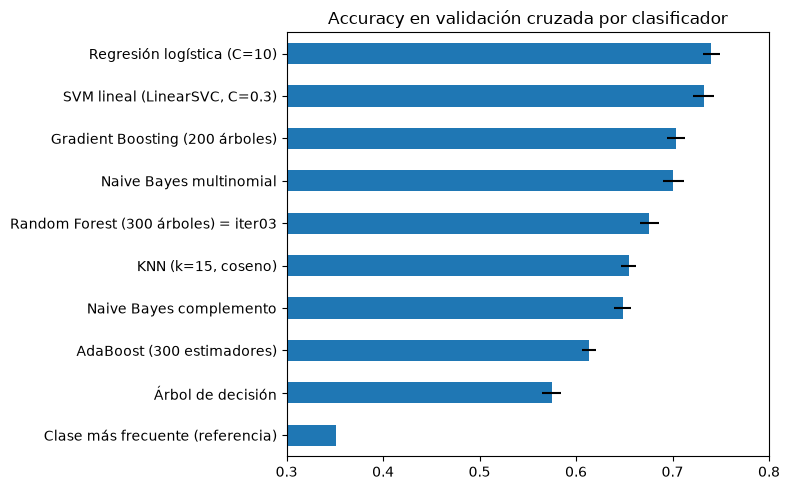

In [18]:
# 5.5 Clasificadores del curso con la representación elegida en 5.2-5.4
REPRESENTACION = dict(sublinear_tf=True, min_df=2, ngram_range=(1, 1))

clasificadores = {
    "Regresión logística (C=10)": regresion_logistica(10),
    "SVM lineal (LinearSVC, C=0.3)": LinearSVC(C=0.3, random_state=SEED),
    "Naive Bayes multinomial": MultinomialNB(),
    "Naive Bayes complemento": ComplementNB(),
    "Árbol de decisión": DecisionTreeClassifier(random_state=SEED),
    "KNN (k=15, coseno)": KNeighborsClassifier(n_neighbors=15, metric="cosine"),
    "Random Forest (300 árboles) = iter03": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "AdaBoost (300 estimadores)": AdaBoostClassifier(n_estimators=300, random_state=SEED),
    "Gradient Boosting (200 árboles)": GradientBoostingClassifier(n_estimators=200, random_state=SEED),
}
for nombre, clf in clasificadores.items():
    evaluar(nombre, Pipeline([("vec", tfidf(**REPRESENTACION)), ("clf", clf)]), "5.5")
evaluar("Clase más frecuente (referencia)", DummyClassifier(strategy="most_frequent"), "5.5")

resultados_clf = tabla("5.5")
display(resultados_clf)

ax = resultados_clf.plot.barh(x="experimento", y="accuracy", xerr="desv. accuracy", legend=False, figsize=(8, 5),
                              title="Accuracy en validación cruzada por clasificador")
ax.invert_yaxis(); ax.set_xlim(0.3, 0.8); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Conclusiones de los clasificadores**

| Clasificador | Accuracy CV | F1 macro |
|---|---|---|
| **Regresión logística (C=10)** | **0,7401** | **0,7515** |
| SVM lineal | 0,7323 | 0,7425 |
| Gradient Boosting | 0,7035 | 0,7133 |
| Naive Bayes multinomial | 0,7010 | 0,7134 |
| Random Forest (= iteración 03) | 0,6760 | 0,6828 |
| KNN (k=15, coseno) | 0,6545 | 0,6559 |
| Naive Bayes complemento | 0,6482 | 0,6442 |
| AdaBoost | 0,6133 | 0,6280 |
| Árbol de decisión | 0,5749 | 0,5867 |
| Clase más frecuente | 0,3509 | 0,1732 |

- **Se cumplen las expectativas:** los modelos lineales (logística y SVM) son los mejores y de los más rápidos; Naive Bayes queda cerca pero por debajo; los modelos de árboles y KNN quedan claramente peor. El árbol solo (0,575) sobreajusta; Random Forest lo mejora (0,676) y Gradient Boosting más (0,704), pero tardando unas 8 veces más que la logística.
- **La iteración 03 (Random Forest) empeoró frente a la logística,** como se esperaba: en una matriz de miles de columnas casi todas en cero, cada árbol divide por una sola palabra y ve muy poca señal. Esto descartó una dirección: **el problema no se resuelve con un clasificador más complejo sobre la misma representación.**
- **Todos superan la línea base del 35 %, pero ninguno pasa de ~0,74.** Se elige la **regresión logística**: la mejor accuracy y el mejor F1 macro, rápida, y sus coeficientes se pueden interpretar.

### 5.6 Ajuste y ensamble sobre el texto completo (iteraciones 04 y 05)
Antes de concluir que la bolsa de palabras llegó a su límite, se le dan dos oportunidades más:

- **Iteración 04:** búsqueda en malla (`GridSearchCV`) de los hiperparámetros de la logística junto con los de la representación: rango de n-gramas, `min_df` y `C`. Son 2 × 3 × 4 = 24 combinaciones × 5 pliegues = 120 entrenamientos.
- **Iteración 05:** *stacking* de los tres mejores modelos lineales (logística, SVM y Naive Bayes). Un metamodelo (otra logística) aprende a combinar sus salidas. Para que no aprenda de predicciones hechas sobre los mismos datos con que se entrenaron los modelos base, `StackingClassifier` genera esas salidas con una validación cruzada interna de 5 pliegues.

In [19]:
# 5.6 a) Iteración 04: búsqueda en malla de la logística (representación + regularización)
malla = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df": [1, 2, 3],
    "clf__C": [1, 3, 10, 30],
}
busqueda = GridSearchCV(Pipeline([("vec", tfidf()), ("clf", regresion_logistica())]),
                        malla, cv=CV, scoring="accuracy", n_jobs=-1)
busqueda.fit(X_ent, y_ent)
print(f"Combinaciones: {len(busqueda.cv_results_['params'])} x 5 pliegues = "
      f"{len(busqueda.cv_results_['params']) * 5} entrenamientos")
print("Mejores hiperparámetros:", busqueda.best_params_)

top = (pd.DataFrame(busqueda.cv_results_)
       [["param_vec__ngram_range", "param_vec__min_df", "param_clf__C", "mean_test_score", "std_test_score"]]
       .sort_values("mean_test_score", ascending=False).head(8).round(4)
       .rename(columns={"param_vec__ngram_range": "n-gramas", "param_vec__min_df": "min_df", "param_clf__C": "C",
                        "mean_test_score": "accuracy", "std_test_score": "desv."}))
display(top)
evaluar("iter04: logística ajustada (GridSearchCV)", clone(busqueda.best_estimator_), "5.6")

# 5.6 b) Iteración 05: stacking de logística + SVM lineal + Naive Bayes, con una logística como metamodelo
stacking = Pipeline([
    ("vec", tfidf(sublinear_tf=True, min_df=2)),
    ("clf", StackingClassifier([("lr", regresion_logistica(10)),
                                ("svm", LinearSVC(C=0.3, random_state=SEED)),
                                ("nb", MultinomialNB())],
                               final_estimator=LogisticRegression(max_iter=3000),
                               cv=StratifiedKFold(5, shuffle=True, random_state=SEED))),
])
evaluar("iter05: stacking (LR + SVM + NB -> LR)", stacking, "5.6")

print("\nLas iteraciones 01 a 05, todas con el texto completo:")
display(pd.DataFrame([f for f in experimentos if "iter0" in f["experimento"]])
        [["experimento", "accuracy", "desv. accuracy", "F1 macro"]]
        .sort_values("experimento").round(4).reset_index(drop=True))

Combinaciones: 24 x 5 pliegues = 120 entrenamientos
Mejores hiperparámetros: {'clf__C': 10, 'vec__min_df': 2, 'vec__ngram_range': (1, 1)}


,n-gramas,min_df,C,accuracy,desv.
14,"(1, 1)",2,10,0.7407,0.0086
16,"(1, 1)",3,10,0.7373,0.0101
15,"(1, 2)",2,10,0.7367,0.0156
12,"(1, 1)",1,10,0.7366,0.0117
20,"(1, 1)",2,30,0.7365,0.0056
9,"(1, 2)",2,3,0.7357,0.0152
22,"(1, 1)",3,30,0.7354,0.0102
11,"(1, 2)",3,3,0.7350,0.0136


iter04: logística ajustada (GridSearchCV)               accuracy 0.7407 ± 0.0086 | F1 macro 0.7521 | pliegues [0.75  0.736 0.745 0.746 0.726]
iter05: stacking (LR + SVM + NB -> LR)                  accuracy 0.7423 ± 0.0130 | F1 macro 0.7543 | pliegues [0.754 0.745 0.738 0.756 0.72 ]

Las iteraciones 01 a 05, todas con el texto completo:


,experimento,accuracy,desv. accuracy,F1 macro
0,Random Forest (300 árboles) = iter03,0.6760,0.0097,0.6828
1,iter01: bolsa de palabras + Naive Bayes,0.7047,0.0129,0.7171
2,iter02: TF-IDF + LR por defecto,0.7252,0.0123,0.7359
3,iter04: logística ajustada (GridSearchCV),0.7407,0.0086,0.7521
4,iter05: stacking (LR + SVM + NB -> LR),0.7423,0.0130,0.7543


**Resultado**
- **Iteración 04 (0,7407):** la mejor combinación es unigramas, `min_df = 2` y `C = 10`, prácticamente la misma que se eligió paso a paso en 5.2 y 5.3 (0,7401). La búsqueda confirma esas decisiones y suma +1,5 puntos frente a la logística por defecto de la iteración 02 (0,7252); casi toda la mejora viene de `C` y de `min_df`. Las 8 mejores combinaciones están entre 0,735 y 0,741: una meseta, no hay un punto claramente mejor.
- **Iteración 05 (0,7423):** el stacking es el mejor número de la sección, pero solo 0,2 puntos sobre la logística sola, con una desviación entre pliegues de ±1,3 puntos: la diferencia no es significativa. Los tres modelos ven la misma representación y por eso se equivocan en las mismas reseñas; no hay diversidad que combinar.

**¿En qué valor se estanca la bolsa de palabras y por qué?** En **~0,74**: con cualquier representación (5.2), con o sin n-gramas (5.3), con cualquier preprocesamiento (5.4), con cualquier clasificador (5.5), con hiperparámetros ajustados y con un ensamble (5.6). Si el techo no depende del clasificador, el límite está en la **representación**. Las reseñas positivas y negativas usan las mismas palabras ("excelente" y "decepcionante" aparecen en las dos); lo que cambia es **cuál opinión va al final**, y la bolsa de palabras cuenta las palabras sin importar su orden. La sección 6 pone a prueba esta hipótesis.

### 5.7 Función para generar envíos a Kaggle
La función entrena el modelo con **todo** `train.csv` (las 12.000 reseñas etiquetadas), predice `eval.csv`, valida el formato (`id,answer`, 3.000 filas, mismos ids que `sample_submission.csv`, etiquetas válidas) y guarda el archivo en `submissions/`. Además se usa para comprobar algo importante para la replicabilidad: que los modelos de esta sección, entrenados desde este notebook, producen **exactamente** los archivos que se subieron a Kaggle en las iteraciones 01 a 05 (carpeta `kaggle_iteraciones/`).

In [20]:
# 5.7 Función para generar envíos a Kaggle
muestra = pd.read_csv(DATA_DIR / "sample_submission.csv")
ENVIOS_KAGGLE_DIR = Path("kaggle_iteraciones")  # los archivos que se subieron a Kaggle


def generar_envio(modelo, nombre, guardar=True):
    """Entrena con todo train.csv, predice eval.csv, valida el formato y (opcional) guarda submissions/<nombre>.csv."""
    modelo = clone(modelo).fit(train["text"], train["label"])
    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text"])})

    assert list(envio.columns) == ["id", "answer"], "las columnas deben ser id,answer"
    assert len(envio) == 3000 and envio["id"].is_unique, "deben ser 3.000 ids sin repetir"
    assert set(envio["id"]) == set(muestra["id"]), "los ids no coinciden con sample_submission.csv"
    assert envio["answer"].isin(LABELS).all(), "hay etiquetas que no son negativo/neutral/positivo"

    if guardar:
        envio.to_csv(SUB_DIR / f"{nombre}.csv", index=False)
        print(f"Guardado {SUB_DIR / (nombre + '.csv')}")
    print(f"{nombre}: predicciones por clase {envio['answer'].value_counts().to_dict()}")
    return modelo, envio


# Comprobación: los modelos de esta sección reproducen los archivos que se subieron a Kaggle
modelos_s5 = {
    "iter01_bolsa_naive_bayes": Pipeline([("vec", bolsa()), ("clf", MultinomialNB())]),
    "iter02_tfidf_logistica": Pipeline([("vec", tfidf()), ("clf", regresion_logistica())]),
    "iter03_tfidf_random_forest": Pipeline([("vec", tfidf(**REPRESENTACION)),
                                            ("clf", RandomForestClassifier(n_estimators=300, random_state=SEED))]),
    "iter04_logistica_ajustada": busqueda.best_estimator_,
    "iter05_stacking_clasico": stacking,
}
comparacion = []
for nombre, modelo in modelos_s5.items():
    _, envio = generar_envio(modelo, nombre, guardar=False)
    subido = pd.read_csv(ENVIOS_KAGGLE_DIR / f"{nombre}.csv")
    comparacion.append({"envío": nombre, "predicciones distintas al archivo subido": int((envio["answer"].values != subido["answer"].values).sum())})
display(pd.DataFrame(comparacion))

iter01_bolsa_naive_bayes: predicciones por clase {'negativo': 1077, 'positivo': 1074, 'neutral': 849}
iter02_tfidf_logistica: predicciones por clase {'negativo': 1078, 'positivo': 1073, 'neutral': 849}
iter03_tfidf_random_forest: predicciones por clase {'positivo': 1045, 'negativo': 1025, 'neutral': 930}
iter04_logistica_ajustada: predicciones por clase {'positivo': 1093, 'negativo': 1072, 'neutral': 835}
iter05_stacking_clasico: predicciones por clase {'positivo': 1095, 'negativo': 1080, 'neutral': 825}


,envío,predicciones distintas al archivo subido
0,iter01_bolsa_naive_bayes,0
1,iter02_tfidf_logistica,0
2,iter03_tfidf_random_forest,0
3,iter04_logistica_ajustada,0
4,iter05_stacking_clasico,0


**Resultado:** los cinco modelos, reentrenados con todo `train.csv` desde este notebook, producen **exactamente** los mismos archivos que se subieron a Kaggle (0 predicciones distintas de 3.000 en cada uno). Los envíos de las iteraciones 01 a 05 son reproducibles a partir de este notebook.

## 6. Más allá de los n-gramas: dónde está la opinión
La sección 5 terminó con una hipótesis: la bolsa de palabras se estanca en ~0,74 porque no sabe **cuál opinión va al final**. Esta sección la pone a prueba sin salir de las técnicas del curso: se sigue usando TF-IDF y regresión logística, pero aplicados a **partes** del texto.

> ⚠️ Antes de usar esto en el modelo final, confirmar con la profesora o el monitor que segmentar el texto antes de vectorizar está permitido. _(TODO: anotar la respuesta y la fecha)_
>
> Toda función que vaya dentro del pipeline se define con `def` en este notebook (nunca con `lambda`), para que el modelo se pueda guardar y volver a cargar.

### 6.1 ¿Qué parte del texto tiene la información?
Se definen funciones que extraen una parte de cada reseña: la **primera oración**, la **última oración** y **lo que sigue al último conector contrastivo** ("aun así", "eso sí", "pero", "al final"…; si no hay conector, se usa la última oración). Cada función se mete en el pipeline con `FunctionTransformer`, antes del TF-IDF. Así la extracción se aplica igual al entrenar, al validar y al predecir `eval.csv`, y el modelo guardado sigue recibiendo el texto original.

Se entrena el **mismo modelo** (TF-IDF sublineal, `min_df = 2`, logística con `C = 10`) sobre cada parte y se compara con el texto completo. Además de la accuracy se mira el F1 de cada clase, para ver qué gana y qué pierde cada vista.

In [21]:
# 6.1 ¿Qué parte del texto tiene la información?
CONECTORES = ["aun asi", "eso si", "por otro lado", "por cierto", "de paso", "al final", "con todo",
              "a fin de cuentas", "sin embargo", "en fin", "despues de todo", "pero", "aunque", "ahora",
              "ademas", "no obstante", "de todas formas", "igual", "lo unico", "nada mas"]
PATRON_CONECTOR = re.compile(r"\b(" + "|".join(CONECTORES) + r")\b")
PATRON_ORACION = re.compile(r"(?<=[.;:!?])\s+")  # una oración termina en . ; : ! ? seguido de espacio


def oraciones(texto):
    """Parte un texto ya corregido en oraciones."""
    return [o for o in PATRON_ORACION.split(texto.strip()) if o]


def texto_completo(textos):
    return [corregir_texto(t) for t in textos]


def primera_oracion(textos):
    return [oraciones(corregir_texto(t))[0] for t in textos]


def ultima_oracion(textos):
    return [oraciones(corregir_texto(t))[-1] for t in textos]


def tras_ultimo_conector(textos):
    """Desde el último conector contrastivo hasta el final (la última oración si no hay conector)."""
    salida = []
    for t in textos:
        t = corregir_texto(t)
        conectores = list(PATRON_CONECTOR.finditer(t))
        salida.append(t[conectores[-1].start():] if conectores else oraciones(t)[-1])
    return salida


def vista(funcion, **parametros):
    """Una vista del texto: extraer una parte de la reseña y representarla con TF-IDF."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, **parametros))])


# Qué ve el modelo con cada vista, en una reseña mixta del entrenamiento
ejemplo = X_ent[X_ent.str.contains("Aun así")].iloc[0]
print("Reseña:", ejemplo, "| etiqueta:", y_ent[X_ent == ejemplo].iloc[0], "\n")
for funcion in [primera_oracion, ultima_oracion, tras_ultimo_conector]:
    print(f"{funcion.__name__:<22} -> {funcion([ejemplo])[0]}")

# Mismo modelo (TF-IDF sublineal, min_df=2, logística C=10) sobre cada parte del texto
partes = {"Texto completo": texto_completo, "Solo la primera oración": primera_oracion,
          "Solo la última oración (= iter06)": ultima_oracion,
          "Solo lo que sigue al último conector (= iter07)": tras_ultimo_conector}
f1_por_clase = {}
print()
for nombre, funcion in partes.items():
    modelo = Pipeline([("vista", vista(funcion)), ("clf", regresion_logistica(10))])
    evaluar(nombre, modelo, "6.1")
    pred = cross_val_predict(modelo, X_ent, y_ent, cv=CV, n_jobs=-1)
    f1_por_clase[nombre] = f1_score(y_ent, pred, labels=LABELS, average=None)

display(tabla("6.1"))
print("F1 por clase (predicciones de validación cruzada):")
display(pd.DataFrame(f1_por_clase, index=LABELS).T.round(3))

Reseña: Compré esto hace un par de meses en una tienda por internet, tardó como cuatro días en llegar. Lo uso para el gimnasio casi todos los días. He de decir que la conexión luce desagradable para lo que cuesta. Aun así, el cable quedó muy bueno sin exagerar. | etiqueta: positivo 

primera_oracion        -> compre esto hace un par de meses en una tienda por internet, tardo como cuatro dias en llegar.
ultima_oracion         -> aun asi, el cable quedo muy bueno sin exagerar.
tras_ultimo_conector   -> aun asi, el cable quedo muy bueno sin exagerar.

Texto completo                                          accuracy 0.7401 ± 0.0090 | F1 macro 0.7515 | pliegues [0.751 0.732 0.739 0.749 0.729]
Solo la primera oración                                 accuracy 0.4952 ± 0.0204 | F1 macro 0.4992 | pliegues [0.503 0.479 0.508 0.521 0.465]
Solo la última oración (= iter06)                       accuracy 0.8509 ± 0.0088 | F1 macro 0.8537 | pliegues [0.856 0.842 0.859 0.859 0.839]
Solo lo que sigue a

,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,Solo la última oración (= iter06),0.8509,0.0088,0.8537,0.4816
1,Solo lo que sigue al último conector (= iter07),0.8315,0.0059,0.8334,0.5865
2,Texto completo,0.7401,0.0090,0.7515,0.6881
3,Solo la primera oración,0.4952,0.0204,0.4992,0.5670


F1 por clase (predicciones de validación cruzada):


,negativo,neutral,positivo
Texto completo,0.632,0.987,0.636
Solo la primera oración,0.432,0.613,0.453
Solo la última oración (= iter06),0.824,0.922,0.815
Solo lo que sigue al último conector (= iter07),0.805,0.902,0.793


**Resultado**

| Parte del texto | Accuracy CV | F1 negativo | F1 neutral | F1 positivo |
|---|---|---|---|---|
| Texto completo | 0,7401 | 0,632 | **0,987** | 0,636 |
| Solo la primera oración | 0,4952 | 0,432 | 0,613 | 0,453 |
| **Solo la última oración (iteración 06)** | **0,8509** | **0,824** | 0,922 | **0,815** |
| Solo lo que sigue al último conector (iteración 07) | 0,8315 | 0,805 | 0,902 | 0,793 |

- **Se confirma la hipótesis: la información está al final.** Una sola oración, la última, supera al texto completo por **+11 puntos** (0,74 → 0,85). Es el salto más grande del proyecto. La primera oración, en cambio, apenas llega a 0,50: casi siempre es logística ("lo compré hace un mes, llegó en tres días").
- **El ejemplo lo muestra:** en *"…la conexión luce desagradable… Aun así, el cable quedó muy bueno"* (positiva), el texto completo tiene una palabra negativa y una positiva; la última oración solo tiene la opinión que decide.
- **Lo que sigue al último conector (iteración 07) es peor que la última oración** (0,8315). Cuando el conector está en medio de una oración larga corta la opinión, y en las reseñas sin conector termina usando la última oración de todos modos.
- **Pero cada vista sola pierde algo:** con el texto completo `neutral` era casi perfecta (F1 0,987); con solo la última oración baja a 0,922, porque se pierde el vocabulario descriptivo del resto de la reseña, que era lo que la identificaba. El texto completo reconoce `neutral`; el final reconoce la opinión decisiva. **Siguiente paso: usarlas juntas.**

### 6.2 Combinar el texto completo con sus partes
Con `FeatureUnion` se unen las vistas: cada una produce su propio TF-IDF y se ponen lado a lado, así que una misma palabra tiene una columna en el texto completo y otra en la última oración, y el modelo les puede dar pesos distintos ("excelente" en cualquier parte frente a "excelente" al final). Se agregan una a la vez sobre el texto completo para medir cuánto aporta cada una. Como al unir vistas hay más columnas, la logística usa `C = 3` (más regularización).

In [22]:
# 6.2 Combinar el texto completo con sus partes, agregando una vista a la vez
combinaciones = {
    "Solo el texto completo (C=3)": [("completo", texto_completo)],
    "Completo + última oración": [("completo", texto_completo), ("ultima", ultima_oracion)],
    "Completo + tras el conector": [("completo", texto_completo), ("tras_conector", tras_ultimo_conector)],
    "Completo + tras el conector + última oración (= iter08)": [("completo", texto_completo),
                                                                 ("tras_conector", tras_ultimo_conector),
                                                                 ("ultima", ultima_oracion)],
}
modelos_s6 = {}
for nombre, vistas in combinaciones.items():
    modelo = Pipeline([("vistas", FeatureUnion([(n, vista(f)) for n, f in vistas])),
                       ("clf", regresion_logistica(3))])
    modelos_s6[nombre] = modelo
    evaluar(nombre, modelo, "6.2", vistas=len(vistas))
display(tabla("6.2"))

# Los envíos de esta sección reproducen los archivos que se subieron a Kaggle
envios_s6 = {
    "iter06_ultima_oracion": Pipeline([("vista", vista(ultima_oracion)), ("clf", regresion_logistica(10))]),
    "iter07_tras_ultimo_conector": Pipeline([("vista", vista(tras_ultimo_conector)), ("clf", regresion_logistica(10))]),
    "iter08_tres_vistas": modelos_s6["Completo + tras el conector + última oración (= iter08)"],
}
comparacion = []
for nombre, modelo in envios_s6.items():
    _, envio = generar_envio(modelo, nombre, guardar=False)
    subido = pd.read_csv(ENVIOS_KAGGLE_DIR / f"{nombre}.csv")
    comparacion.append({"envío": nombre, "predicciones distintas al archivo subido": int((envio["answer"].values != subido["answer"].values).sum())})
display(pd.DataFrame(comparacion))

Solo el texto completo (C=3)                            accuracy 0.7354 ± 0.0085 | F1 macro 0.7467 | pliegues [0.743 0.73  0.739 0.743 0.721]
Completo + última oración                               accuracy 0.8798 ± 0.0142 | F1 macro 0.8848 | pliegues [0.897 0.864 0.889 0.886 0.862]
Completo + tras el conector                             accuracy 0.8740 ± 0.0100 | F1 macro 0.8792 | pliegues [0.888 0.871 0.882 0.87  0.859]
Completo + tras el conector + última oración (= iter08) accuracy 0.8869 ± 0.0089 | F1 macro 0.8915 | pliegues [0.895 0.884 0.897 0.886 0.872]


,experimento,vistas,accuracy,desv. accuracy,F1 macro,segundos
0,Completo + tras el conector + última oración (...,3,0.8869,0.0089,0.8915,1.4991
1,Completo + última oración,2,0.8798,0.0142,0.8848,1.0412
2,Completo + tras el conector,2,0.8740,0.0100,0.8792,1.1677
3,Solo el texto completo (C=3),1,0.7354,0.0085,0.7467,0.6101


iter06_ultima_oracion: predicciones por clase {'negativo': 1071, 'positivo': 1021, 'neutral': 908}
iter07_tras_ultimo_conector: predicciones por clase {'negativo': 1067, 'positivo': 999, 'neutral': 934}
iter08_tres_vistas: predicciones por clase {'negativo': 1079, 'positivo': 1075, 'neutral': 846}


,envío,predicciones distintas al archivo subido
0,iter06_ultima_oracion,0
1,iter07_tras_ultimo_conector,0
2,iter08_tres_vistas,0


**Resultado**

| Vistas | Accuracy CV | F1 macro | Score público Kaggle |
|---|---|---|---|
| Solo el texto completo (`C = 3`) | 0,7354 | 0,7467 | — |
| Completo + última oración | 0,8798 | 0,8848 | — |
| Completo + tras el conector | 0,8740 | 0,8792 | — |
| **Completo + tras el conector + última oración (iteración 08)** | **0,8869** | **0,8915** | **0,88111** |
| *Referencia: solo la última oración (iteración 06)* | *0,8509* | *0,8537* | *0,84777* |
| *Referencia: solo tras el conector (iteración 07)* | *0,8315* | *0,8334* | *0,83555* |

- **Agregar el final al texto completo es la mejora decisiva:** de 0,7354 a 0,8798 (+14 puntos) con la última oración, o a 0,8740 con lo que sigue al conector. Juntar el texto completo con una parte final también supera a cualquier parte sola (0,85): el texto completo recupera lo que la parte final perdía, sobre todo para reconocer `neutral`.
- **Las tres vistas juntas son la mejor combinación** (0,8869), +0,7 puntos sobre la mejor pareja. La última oración y lo que sigue al conector se parecen, pero no son iguales: cuando el conector está en medio de una oración, cada vista corta la reseña en un lugar distinto, y el modelo aprende de las dos.
- **La validación cruzada predice bien a Kaggle:** en las tres iteraciones de esta sección la diferencia entre la CV y el score público es menor a 1 punto, y el orden es el mismo (08 > 06 > 07). La iteración 07 se envió para comprobar si el conector era mejor señal que la oración; la CV ya anticipaba que no, y Kaggle lo confirmó.
- **Reproducibilidad:** los tres modelos, reentrenados desde este notebook, producen exactamente los archivos subidos a Kaggle (0 diferencias de 3.000).

**Decisión:** la combinación de las tres vistas (iteración 08) es la base para la sección 7. Quedan ~11 puntos de error, casi todos confusiones entre `positivo` y `negativo`; la sección 7 busca cómo combinar mejor las vistas para reducirlos.

## 7. Combinación de vistas por stacking
La iteración 08 suma las tres vistas dentro de **un solo** modelo lineal. Esta sección prueba otra forma de combinarlas: entrenar **un modelo por vista** y que un **metamodelo** aprenda cuánto creerle a cada uno.

Sobre el ajuste de hiperparámetros: la búsqueda en malla de la logística se hizo en 5.6 (iteración 04, 120 entrenamientos), y sus resultados (`min_df = 2`, `C` entre 3 y 10) se usan aquí como punto de partida.

### 7.1 Iteración 09: un modelo por vista y un stacking que los combina
Cada modelo base es una regresión logística (`C = 3`) entrenada con una sola vista. Además de las de la sección 6, se agregan tres vistas nuevas:

- **Primera y penúltima oración:** en una reseña mixta la opinión "contraria" suele estar justo antes del conector; ver la penúltima ayuda a entender el contraste completo.
- **Palabras marcadas con su conector:** cada palabra lleva pegado el conector que abre su oración ("bueno" después de "aun así" se vuelve `aunasi_bueno`), para que el modelo aprenda qué conectores hacen ganar a lo que sigue.
- **Cierre indeciso:** marca si la reseña termina con una frase de indecisión ("tengo sentimientos encontrados", "ni fu ni fa", "cada quien que juzgue"). En esas reseñas el final no es una opinión.

`StackingClassifier` genera las probabilidades de cada modelo base con una **validación cruzada interna** de 5 pliegues, para que el metamodelo (una logística) aprenda de predicciones sobre reseñas que esos modelos no vieron. Costo: 8 modelos base × (5 pliegues internos + 1 ajuste final) = 48 entrenamientos por cada ajuste, y × 5 pliegues de la validación cruzada externa = **240 entrenamientos** para medirlo.

In [23]:
# 7.1 Iteración 09: un modelo por vista y un stacking que los combina
def penultima_oracion(textos):
    salida = []
    for t in textos:
        partes = oraciones(corregir_texto(t))
        salida.append(partes[-2] if len(partes) > 1 else "")
    return salida


def con_conector(textos):
    """Cada palabra lleva pegado el conector que abre su oración: 'aunasi_feliz', 'porotrolado_harto', 'nada_llego'."""
    salida = []
    for t in textos:
        tokens = []
        for o in oraciones(corregir_texto(t)):
            conector = next((c for c in CONECTORES + ["la verdad"] if o.startswith(c)), "nada").replace(" ", "")
            tokens += [f"{conector}_{p}" for p in re.findall(r"\w\w+", o)]
        salida.append(" ".join(tokens))
    return salida


CIERRE = re.compile(r"sentimientos encontrados|con dudas|no me decido|cada quien|a criterio|ni lo mejor ni lo peor"
                    r"|ni tan bueno ni tan malo|hay de todo|sopes|para gustos|no se si me quedo|lo dejo a tu"
                    r"|cada cosa por su lado|nomas cuento|juzgue|no se que pensar|ahi lo dejo|mis dudas|ni fu ni fa"
                    r"|no sabria|en duda|que recomendar|de cada lado|otras no|no se bien")


def cierre_indeciso(textos):
    """Marca si la reseña cierra con una frase de indecisión ("tengo sentimientos encontrados", "ni fu ni fa")."""
    return ["cierre_si" if CIERRE.search(corregir_texto(t)) else "cierre_no" for t in textos]


def clasificador_de_vista(funcion, C=3):
    """Regresión logística entrenada con una sola vista del texto (modelo base del stacking)."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def tres_vistas(C=3):
    """El mejor modelo de una sola etapa (iteración 08): texto completo + tras el último conector + última oración."""
    return Pipeline([("vistas", FeatureUnion([("completo", vista(texto_completo)),
                                              ("tras_conector", vista(tras_ultimo_conector)),
                                              ("ultima", vista(ultima_oracion))])),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base():
    return [("tres_vistas", tres_vistas()),
            ("completo", clasificador_de_vista(texto_completo)),
            ("tras_conector", clasificador_de_vista(tras_ultimo_conector)),
            ("ultima", clasificador_de_vista(ultima_oracion)),
            ("primera", clasificador_de_vista(primera_oracion)),
            ("penultima", clasificador_de_vista(penultima_oracion)),
            ("con_conector", clasificador_de_vista(con_conector)),
            ("cierre", clasificador_de_vista(cierre_indeciso, C=1))]


# Qué ven las vistas nuevas, en la misma reseña de 6.1
print("penultima_oracion ->", penultima_oracion([ejemplo])[0])
print("con_conector      -> ...", " ".join(con_conector([ejemplo])[0].split()[-8:]))
print("cierre_indeciso   ->", cierre_indeciso([ejemplo])[0])

# ¿Qué tan frecuente es un cierre indeciso y qué etiqueta tiene?
cierre_ent = pd.Series(cierre_indeciso(X_ent), index=X_ent.index)
print(f"\nReseñas de entrenamiento con cierre indeciso: {(cierre_ent == 'cierre_si').mean():.1%}")
display(pd.crosstab(cierre_ent, y_ent, normalize="index").round(3))

iter09 = StackingClassifier(modelos_base(), final_estimator=LogisticRegression(C=1, max_iter=3000),
                            cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
evaluar("iter09: stacking de vistas (metamodelo logístico)", iter09, "7")

_, envio = generar_envio(iter09, "iter09_stacking_de_vistas", guardar=False)
subido = pd.read_csv(ENVIOS_KAGGLE_DIR / "iter09_stacking_de_vistas.csv")
print("Predicciones distintas al archivo subido a Kaggle:", int((envio["answer"].values != subido["answer"].values).sum()))

penultima_oracion -> he de decir que la conexion luce desagradable para lo que cuesta.
con_conector      -> ... aunasi_asi aunasi_el aunasi_cable aunasi_quedo aunasi_muy aunasi_bueno aunasi_sin aunasi_exagerar
cierre_indeciso   -> cierre_no

Reseñas de entrenamiento con cierre indeciso: 12.4%


label,negativo,neutral,positivo
row_0,,,
cierre_no,0.329,0.338,0.333
cierre_si,0.504,0.015,0.481


iter09: stacking de vistas (metamodelo logístico)       accuracy 0.8942 ± 0.0068 | F1 macro 0.8990 | pliegues [0.898 0.895 0.901 0.895 0.881]
iter09_stacking_de_vistas: predicciones por clase {'negativo': 1086, 'positivo': 1083, 'neutral': 831}
Predicciones distintas al archivo subido a Kaggle: 2


**Resultado**
- **Iteración 09: 0,8942 ± 0,0068** (F1 macro 0,8990), **+0,7 puntos** sobre la iteración 08 (0,8869), y con menos variación entre pliegues (±0,68 frente a ±0,89). En Kaggle obtuvo **0,89111**, de nuevo a menos de 1 punto de la validación cruzada.
- **El cierre indeciso explica buena parte del error que queda:** el 12,4 % de las reseñas de entrenamiento cierra con una frase de indecisión, y entre ellas la etiqueta está prácticamente partida a la mitad (50,4 % negativas, 48,1 % positivas, 1,5 % neutrales). En esas reseñas el final no dice nada, así que ninguna vista basada en el final puede decidir. El modelo de esa vista no sirve para predecir la polaridad, pero le avisa al metamodelo cuándo no confiar en el final.
- **La mejora es moderada porque el metamodelo es lineal:** puede ponderar a cada vista, pero no aprender reglas del tipo "si el final es positivo **y** la reseña cierra indecisa, entonces…".
- **Reproducibilidad:** reentrenado desde este notebook, el modelo coincide con el archivo subido a Kaggle en 2.998 de 3.000 predicciones (los conteos por clase son idénticos). Las 2 diferencias son reseñas casi empatadas entre `positivo` y `negativo`, en las que las diferencias numéricas entre sistemas operativos, acumuladas en los 48 entrenamientos del stacking, inclinan el empate hacia el otro lado.

### 7.2 Iteración 10: stacking ampliado con un metamodelo de boosting
Dos cambios sobre la iteración 09:

1. **Cuatro modelos base más:**
   - **Última oración de opinión** (`UltimaOpinion`): salta hacia atrás las oraciones finales de relleno o de indecisión hasta encontrar la última que tiene una palabra de opinión. Las palabras de opinión se aprenden en `fit` (las 400 de más peso en una logística positivo contra negativo), así que en la validación cruzada se aprenden solo con la parte de entrenamiento de cada pliegue, sin fuga de información.
   - **N-gramas de caracteres** (de 2 a 5 letras) sobre lo que sigue al conector y sobre la última oración: "mdia" o "cincco" no están en el vocabulario, pero comparten trozos con "media" y "cinco". Toleran los errores de tipeo que se vieron en el EDA.
   - **Lo que va antes del último conector:** la opinión que el conector contradice.
2. **Metamodelo de boosting** (`HistGradientBoostingClassifier`, 200 árboles, `learning_rate = 0.05`): al ser de árboles, puede aprender **interacciones** entre las vistas que la logística no ve, como "si la reseña cierra indecisa, no confiar en la última oración".

Costo: 12 modelos base × 6 ajustes = 72 entrenamientos por cada ajuste del stacking, y **360** para medirlo con la validación cruzada.

In [24]:
# 7.2 Iteración 10: stacking ampliado con un metamodelo de boosting
class UltimaOpinion(BaseEstimator, TransformerMixin):
    """Última oración que contiene alguna palabra de opinión y no es un cierre indeciso.

    Las palabras de opinión se aprenden en `fit` (las `k` de mayor peso en una regresión logística
    positivo contra negativo), así que en cada pliegue se aprenden solo con su parte de entrenamiento.
    """

    def __init__(self, k=400):
        self.k = k

    def fit(self, X, y):
        y = np.asarray(y)
        polares = y != "neutral"
        vectorizador = TfidfVectorizer(min_df=3)
        M = vectorizador.fit_transform(texto_completo(np.asarray(X)[polares]))
        pesos = LogisticRegression(C=1, max_iter=3000).fit(M, y[polares]).coef_[0]
        vocabulario = vectorizador.get_feature_names_out()
        self.palabras_opinion_ = set(vocabulario[np.argsort(-np.abs(pesos))[:self.k]])
        return self

    def transform(self, X):
        salida = []
        for t in X:
            partes = oraciones(corregir_texto(t))
            elegida = next((o for o in reversed(partes) if not CIERRE.search(o)
                            and set(re.findall(r"\w\w+", o)) & self.palabras_opinion_), partes[-1])
            salida.append(elegida)
        return salida


def antes_del_ultimo_conector(textos):
    salida = []
    for t in textos:
        t = corregir_texto(t)
        conectores = list(PATRON_CONECTOR.finditer(t))
        salida.append(t[:conectores[-1].start()] if conectores else "")
    return salida


def clasificador_de_caracteres(funcion, C=3):
    """N-gramas de caracteres (2 a 5) dentro de cada palabra: tolera errores de tipeo ("mdia", "cincco")."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, analyzer="char_wb", ngram_range=(2, 5))),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base_ampliados():
    ultima_opinion = Pipeline([("parte", UltimaOpinion(k=400)),
                               ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                               ("clf", LogisticRegression(C=3, max_iter=3000))])
    return modelos_base() + [("ultima_opinion", ultima_opinion),
                             ("caracteres_tras_conector", clasificador_de_caracteres(tras_ultimo_conector)),
                             ("caracteres_ultima", clasificador_de_caracteres(ultima_oracion)),
                             ("antes_del_conector", clasificador_de_vista(antes_del_ultimo_conector))]


# Qué elige UltimaOpinion en tres reseñas (aprendiendo las palabras de opinión solo con entrenamiento)
for original, elegida in zip(X_ent[:3], UltimaOpinion().fit(X_ent, y_ent).transform(X_ent[:3])):
    print(f"Última oración: {ultima_oracion([original])[0]}\nÚltima opinión: {elegida}\n")
print("antes_del_ultimo_conector ->", antes_del_ultimo_conector([ejemplo])[0])

iter10 = StackingClassifier(
    modelos_base_ampliados(),
    final_estimator=HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=SEED),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
evaluar("iter10: stacking ampliado (metamodelo de boosting)", iter10, "7")
display(tabla("7"))

_, envio = generar_envio(iter10, "iter10_stacking_boosting", guardar=False)
subido = pd.read_csv(ENVIOS_KAGGLE_DIR / "iter10_stacking_boosting.csv")
print("Predicciones distintas al archivo subido a Kaggle:", int((envio["answer"].values != subido["answer"].values).sum()))

Última oración: por cierto, trae garantia de un ano.
Última opinión: por cierto, trae garantia de un ano.

Última oración: con todo, el material se ve defectuoso la verdad.
Última opinión: con todo, el material se ve defectuoso la verdad.

Última oración: el epmaque no vale lo que cuesta.
Última opinión: el epmaque no vale lo que cuesta.

antes_del_ultimo_conector -> compre esto hace un par de meses en una tienda por internet, tardo como cuatro dias en llegar. lo uso para el gimnasio casi todos los dias. he de decir que la conexion luce desagradable para lo que cuesta. 
iter10: stacking ampliado (metamodelo de boosting)      accuracy 0.9021 ± 0.0105 | F1 macro 0.9067 | pliegues [0.912 0.893 0.912 0.906 0.886]


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,iter10: stacking ampliado (metamodelo de boost...,0.9021,0.0105,0.9067,48.9968
1,iter09: stacking de vistas (metamodelo logístico),0.8942,0.0068,0.8990,25.3920


iter10_stacking_boosting: predicciones por clase {'negativo': 1111, 'positivo': 1061, 'neutral': 828}
Predicciones distintas al archivo subido a Kaggle: 87


**Resultado**
- **Iteración 10: 0,9021 ± 0,0105** (F1 macro 0,9067), **+0,8 puntos** sobre la iteración 09 y la **mejor de todas**: 16 puntos más que la mejor bolsa de palabras del texto completo (0,742) y 55 más que la línea base trivial (0,351). En Kaggle obtuvo **0,89888**, el mejor score público del grupo.
- **Qué aportó:** los modelos base nuevos, sobre todo la última oración *de opinión*, que salta los cierres de relleno, y un metamodelo que puede combinar las vistas con reglas no lineales. Las tres reseñas del ejemplo muestran que, cuando la última oración ya es una opinión, `UltimaOpinion` la deja igual; solo cambia la elección cuando el final es relleno o indecisión.
- **Límite que queda:** el ~12 % de reseñas que cierran con una frase indecisa tiene su etiqueta partida casi a la mitad entre `positivo` y `negativo` (7.1). Si esas reseñas son ambiguas por construcción, ninguna representación del texto puede acertarlas mucho más que al azar, y el techo práctico de cualquier modelo estaría alrededor de 0,93.

**Reproducibilidad: una diferencia importante frente a las iteraciones anteriores.** Reentrenado en este computador, el modelo difiere del archivo subido a Kaggle en **87 de 3.000** predicciones (2,9 %), y su validación cruzada da 0,9021 frente a 0,9012 en el computador donde se generó el envío. Con la misma versión de scikit-learn (1.9.1), la causa son diferencias numéricas mínimas entre sistemas operativos en las probabilidades de los modelos base. Una logística (iteración 09) las absorbe, pero los árboles del metamodelo cortan por umbrales y las amplifican. Por eso, en la sección 9 el modelo entregado es el **mismo modelo guardado que generó el envío de 0,89888** (cargado desde su `.joblib`), no uno reentrenado, y ahí se comprueba que reproduce ese envío.

### 7.3 Iteraciones 11 y 12: negación marcada, última cláusula y ponderación NB-SVM
Desde la iteración 11 cambia **cómo se representa cada vista**, no qué vistas hay:

- **Marcado de negación** (regla escrita a mano): las palabras que siguen a "no", "ni", "nunca", "sin"… hasta el siguiente signo de puntuación llevan el prefijo `no_`. Así "no lo recomiendo" produce `no_recomiendo`, distinto de `recomiendo`.
- **Última cláusula:** además de partir en oraciones, se corta antes de ", pero", " aunque", " y "…, porque a veces las dos opiniones van en la misma oración ("la pantalla es excelente, pero la batería no dura nada").
- **NB-SVM** (Wang y Manning, 2012): bolsa de unigramas y bigramas **binaria** en la que cada columna se multiplica por su *log-count ratio* $r = \log\frac{p/\lVert p\rVert_1}{q/\lVert q\rVert_1}$, donde $p$ y $q$ cuentan en cuántas reseñas de la clase y del resto aparece el término (suavizado $\alpha = 1$). Es una **ponderación de la bolsa de palabras**, como TF-IDF, pero usando las etiquetas: los términos que separan bien las clases pesan más. Se calcula una vez por clase (una contra el resto) y los tres bloques se concatenan. Los $r$ se aprenden en `fit`, así que en la validación cruzada salen solo de la parte de entrenamiento de cada pliegue. El clasificador sigue siendo una regresión logística de scikit-learn.

La **iteración 11** aplicó esto a las vistas de palabras del stack de la iteración 10 y la **12** también a los n-gramas de caracteres (13 modelos base, `modelos_base_nb`). Para medir el efecto de la nueva representación sin el costo de un stacking completo, aquí se compara un solo modelo: las tres vistas de la iteración 08 con NB-SVM y negación (`nb_tres`) frente a las mismas tres vistas con TF-IDF.

In [25]:
# 7.3 Iteraciones 11 y 12: negación marcada, última cláusula y ponderación NB-SVM
# Marcado de negación y segmentación en cláusulas (reglas escritas a mano)
NEGADORES = {"no", "ni", "nunca", "sin", "tampoco", "jamas", "nada", "nadie", "ningun", "ninguna", "ninguno"}
PATRON_TOKEN = re.compile(r"\w+|[.,;:!?]")
PUNTUACION = set(".,;:!?")


def marcar_negacion_texto(texto):
    """'no lo recomiendo, la verdad' -> 'no no_lo no_recomiendo , la verdad' (el alcance termina en la puntuación)."""
    salida, negado = [], False
    for tok in PATRON_TOKEN.findall(texto):
        if tok in PUNTUACION:
            negado = False
            salida.append(tok)
        elif tok in NEGADORES:
            negado = True
            salida.append(tok)
        else:
            salida.append("no_" + tok if negado else tok)
    return " ".join(salida)


def marcar_negacion(textos):
    return [marcar_negacion_texto(t) for t in textos]


# Corte de cláusulas: fin de oración, o coma/espacio antes de un conector ("..., pero", " aunque ", " y ")
PATRON_CLAUSULA = re.compile(r"(?<=[.;:!?])\s+|,\s+(?=(?:pero|aunque|aun asi|sin embargo|eso si|y)\b)"
                             r"|\s+(?=(?:pero|aunque|y)\s)")


def clausulas_texto(texto_corregido):
    return [c.strip(" ,") for c in PATRON_CLAUSULA.split(texto_corregido.strip()) if c and c.strip(" ,")]


def ultima_clausula(textos):
    return [(clausulas_texto(corregir_texto(t)) or [""])[-1] for t in textos]


# NB-SVM (Wang y Manning, 2012): bolsa de n-gramas binaria escalada por el log-count ratio de cada clase
class EscaladoNBClase(BaseEstimator, TransformerMixin):
    """Escalado NB para UNA clase (la k-ésima en orden): r = log((p/|p|) / (q/|q|)), con p = alpha + conteos
    binarios (presencia) en la clase y q = alpha + conteos en el resto (una contra el resto).
    transform devuelve X * r. Los r se aprenden en fit, solo con los datos de entrenamiento del pliegue."""

    def __init__(self, k=0, alpha=1.0):
        self.k = k
        self.alpha = alpha

    def fit(self, X, y):
        y = np.asarray(y)
        Xb = X.tocsr().copy()
        Xb.data = np.ones_like(Xb.data)  # presencia / ausencia
        clase = np.unique(y)[self.k]
        p = self.alpha + np.asarray(Xb[y == clase].sum(0)).ravel()
        q = self.alpha + np.asarray(Xb[y != clase].sum(0)).ravel()
        self.r_ = np.log((p / p.sum()) / (q / q.sum()))
        return self

    def transform(self, X):
        return X.tocsr().multiply(self.r_).tocsr()


def escalado_nb(alpha=1.0):
    """NB-SVM multiclase: un bloque de features escaladas por cada clase (negativo, neutral, positivo),
    concatenados por FeatureUnion: [X * r_neg | X * r_neu | X * r_pos]."""
    return FeatureUnion([(f"clase_{k}", EscaladoNBClase(k=k, alpha=alpha)) for k in range(len(LABELS))])


def bolsa_nb_palabras():
    """Unigramas y bigramas binarios (norma L2) con negación marcada, escalados por NB."""
    return [("neg", FunctionTransformer(marcar_negacion)),
            ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(1, 2), binary=True, use_idf=False, norm="l2")),
            ("nb", escalado_nb(alpha=1.0))]


def vista_nb(funcion):
    return Pipeline([("parte", FunctionTransformer(funcion))] + bolsa_nb_palabras())


def clf_nb(funcion, C=1):
    """Modelo base: una vista del texto -> NB-SVM -> regresión logística."""
    return Pipeline([("vista", vista_nb(funcion)), ("clf", LogisticRegression(C=C, max_iter=3000))])


def clf_char_nb(funcion, C=1):
    """N-gramas de caracteres 2-5 dentro de palabra (toleran tipeos: "mdia", "cincco"), binarios + NB."""
    vista = Pipeline([("parte", FunctionTransformer(funcion)),
                      ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(2, 5), binary=True, use_idf=False,
                                                norm="l2", analyzer="char_wb")),
                      ("nb", escalado_nb(alpha=1.0))])
    return Pipeline([("vista", vista), ("clf", LogisticRegression(C=C, max_iter=3000))])


def nb_tres(C=1):
    """Tres vistas NB-SVM (texto completo, tras el último conector, última oración) unidas -> LR."""
    vistas = [("completo", vista_nb(texto_completo)),
              ("tras_conector", vista_nb(tras_ultimo_conector)),
              ("ultima", vista_nb(ultima_oracion))]
    return Pipeline([("vistas", FeatureUnion(vistas)), ("clf", LogisticRegression(C=C, max_iter=3000))])


def ultima_opinion_nb(C=1):
    return Pipeline([("parte", UltimaOpinion(k=400)),
                     ("neg", FunctionTransformer(marcar_negacion)),
                     ("bow", TfidfVectorizer(min_df=2, ngram_range=(1, 2), binary=True, use_idf=False)),
                     ("nb", escalado_nb()),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def cierre_lr():
    """Indicador de cierre indeciso -> LR (igual que en iter10)."""
    return Pipeline([("parte", FunctionTransformer(cierre_indeciso)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=1, max_iter=3000))])


def modelos_base_nb():
    """Los 13 modelos base del stack NB-SVM (en este orden)."""
    return [("nb_tres", nb_tres()),
            ("completo", clf_nb(texto_completo)),
            ("tras_conector", clf_nb(tras_ultimo_conector)),
            ("ultima", clf_nb(ultima_oracion)),
            ("primera", clf_nb(primera_oracion)),
            ("penultima", clf_nb(penultima_oracion)),
            ("con_conector", clf_nb(con_conector)),
            ("cierre", cierre_lr()),
            ("ultima_opinion", ultima_opinion_nb()),
            ("antes_del_conector", clf_nb(antes_del_ultimo_conector)),
            ("ultima_clausula", clf_nb(ultima_clausula)),
            ("caracteres_tras_conector", clf_char_nb(tras_ultimo_conector)),
            ("caracteres_ultima", clf_char_nb(ultima_oracion))]


# Qué hacen la negación marcada y la última cláusula
print(marcar_negacion([corregir_texto("No lo recomiendo, la verdad. Funciona bien.")])[0])
print(ultima_clausula([corregir_texto("La pantalla es excelente, pero la batería no dura nada.")])[0])

# Mismo modelo de una sola etapa que la iteración 08 (tres vistas unidas -> LR), pero cada vista con NB-SVM y negación
evaluar("Tres vistas con NB-SVM + negación (base nb_tres de las iteraciones 11 a 14)", nb_tres(), "7.3")
print("Referencia, iteración 08 (tres vistas con TF-IDF):",
      tabla("6.2").set_index("experimento").loc["Completo + tras el conector + última oración (= iter08)", "accuracy"])

no no_lo no_recomiendo , la verdad . funciona bien .
pero la bateria no dura nada.
Tres vistas con NB-SVM + negación (base nb_tres de las iteraciones 11 a 14) accuracy 0.8981 ± 0.0079 | F1 macro 0.9022 | pliegues [0.907 0.898 0.906 0.894 0.885]
Referencia, iteración 08 (tres vistas con TF-IDF): 0.8869


**Resultado**
- La misma combinación de tres vistas pasa de **0,8869** con TF-IDF (iteración 08) a **0,8981** con NB-SVM y negación: **+1,1 puntos** con un solo modelo lineal, más que el stacking de 8 modelos de la iteración 09 (0,8942).
- Con todo el stack, las iteraciones 11 y 12 llegaron a **0,9076** y **0,9093** en validación cruzada (medido en sus notebooks de `notebooks_iteraciones/`; no se repiten aquí porque cada stacking tarda varios minutos y la mejora de la representación ya queda demostrada arriba). La 12 sacó 0,89333 en Kaggle, menos que la 10 (0,89888) a pesar de su mejor validación: el score público se calcula con ~900 reseñas y tiene un margen de ±1 punto.

### 7.4 Iteración 13: final sin relleno y polaridad por segmento
El análisis de errores de la iteración 12 mostró que lo evitable que quedaba eran reseñas con **una sola opinión** en las que la última oración es relleno ("lo tengo en la sala") o la opinión tiene una forma poco frecuente. Se agregan dos modelos base (15 en total):

- **`tras_conector_sr` (sin relleno):** antes de tomar lo que sigue al último conector, quita las oraciones finales sin **ninguna palabra de opinión**. Esas palabras **se aprenden en `fit`**: las que aparecen al menos 4 veces más, en proporción, en reseñas polares que en neutrales. No dicen si algo es positivo o negativo, solo que es opinión.
- **`polaridad_segmentos`:** parte la reseña en segmentos (oraciones cortadas en cada conector) y **aprende en `fit` un clasificador de segmentos** negativo/nada/positivo con *supervisión débil*: los segmentos que abre un conector contrastivo ("aun así", "al final") heredan la etiqueta de la reseña, los de reseñas neutrales son "nada", y luego hay dos rondas de autoentrenamiento. Cada palabra se marca con la polaridad de su segmento y su papel (`P_`, `N_`, `Nult_`: última opinión negativa, `C_`: cierre indeciso…) y eso pasa por TF-IDF + regresión logística. Las marcas del entrenamiento salen de una validación cruzada interna para no sobreajustar.

Ninguno de los dos usa una lista de palabras de sentimiento escrita a mano: las listas escritas a mano (conectores agrupados por función, negadores, frases de cierre) son **estructurales**; la polaridad siempre se aprende de los datos de entrenamiento dentro de `fit`.

In [26]:
# 7.4 Iteración 13: final sin relleno y polaridad por segmento (15 modelos base)
from sklearn.multiclass import OneVsRestClassifier


def etiquetas_texto(y):
    """StackingClassifier entrena los modelos base con la y codificada (0, 1, 2 en orden alfabético):
    la devolvemos a texto para que las reglas que miran 'neutral' funcionen igual dentro y fuera del stack."""
    y = np.asarray(y)
    if y.dtype.kind in "iu":
        y = np.asarray(LABELS)[y]
    return y


# Vista sin relleno: tras el último conector, SIN las oraciones de relleno del final
class VistaSinRelleno(BaseEstimator, TransformerMixin):
    """Quita las oraciones de relleno del final de la reseña y devuelve lo que sigue al último conector
    (modo="tras_conector") o la última oración (modo="ultima").

    Palabras de opinión aprendidas en fit: p(palabra | polar) / p(palabra | neutral) >= razon (presencia binaria,
    suavizado +1). No dicen si la palabra es positiva o negativa, solo que aparece en opiniones. Una oración sin
    ninguna palabra de opinión se considera relleno. La y se decodifica porque dentro del stack llega 0/1/2."""

    def __init__(self, modo="tras_conector", razon=4.0, min_df=3):
        self.modo = modo
        self.razon = razon
        self.min_df = min_df

    def fit(self, X, y):
        y = etiquetas_texto(y)
        cv = CountVectorizer(binary=True, min_df=self.min_df, token_pattern=r"\b\w\w+\b")
        A = cv.fit_transform(texto_completo(np.asarray(X, dtype=object)))
        neu = y == "neutral"
        p_neu = (np.asarray(A[neu].sum(0)).ravel() + 1) / (neu.sum() + 2)
        p_pol = (np.asarray(A[~neu].sum(0)).ravel() + 1) / ((~neu).sum() + 2)
        self.palabras_opinion_ = set(cv.get_feature_names_out()[p_pol / p_neu >= self.razon])
        return self

    def _es_opinion(self, o):
        return bool(set(re.findall(r"\b\w\w+\b", o)) & self.palabras_opinion_)

    def transform(self, X):
        salida = []
        for t in X:
            partes = oraciones(corregir_texto(t))
            while len(partes) > 1 and not self._es_opinion(partes[-1]):
                partes = partes[:-1]  # quitar relleno del final (siempre queda al menos una oración)
            if self.modo == "ultima":
                salida.append(partes[-1])
            else:
                texto = " ".join(partes)
                conectores = list(PATRON_CONECTOR.finditer(texto))
                salida.append(texto[conectores[-1].start():] if conectores else partes[-1])
        return salida


def tras_conector_sr(C=3):
    """Modelo base: vista sin relleno (tras el último conector) -> TF-IDF -> LR."""
    return Pipeline([("parte", VistaSinRelleno(modo="tras_conector", razon=4.0)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


# Polaridad por segmento aprendida en fit (supervisión débil con conectores)
# Conectores agrupados por función discursiva (lista ESTRUCTURAL escrita a mano, sin palabras de sentimiento)
GRUPO_CONECTOR = {
    "aun asi": "contra_fuerte", "al final": "contra_fuerte", "con todo": "contra_fuerte",
    "a fin de cuentas": "contra_fuerte", "sin embargo": "contra_fuerte", "en fin": "contra_fuerte",
    "despues de todo": "contra_fuerte", "no obstante": "contra_fuerte", "de todas formas": "contra_fuerte",
    "pero": "contra_debil", "aunque": "contra_debil", "eso si": "concesivo", "ahora": "concesivo",
    "igual": "concesivo", "lo unico": "concesivo", "nada mas": "concesivo",
    "por otro lado": "aditivo", "por cierto": "aditivo", "de paso": "aditivo", "ademas": "aditivo", "y": "aditivo",
}
LISTA_CON = sorted(GRUPO_CONECTOR, key=len, reverse=True)
PATRON_SEG = re.compile(r"(?<!hasta )(?<!por )(?<!desde )\b(" + "|".join(LISTA_CON) + r")\b")
PATRON_PALABRA = re.compile(r"\w+")


def segmentar(texto_corr):
    """Parte un texto corregido en segmentos (texto, conectores_que_lo_abren, índice_oración, es_cierre_indeciso):
    corta en cada oración y antes de cada conector de GRUPO_CONECTOR."""
    segs = []
    ors = oraciones(texto_corr)
    for k, o in enumerate(ors):
        trozos, inicio, actual_con = [], 0, []
        for m in PATRON_SEG.finditer(o):
            previo = o[inicio:m.start()].strip(" ,.;:!?")
            if previo and PATRON_PALABRA.search(previo):
                trozos.append((previo, actual_con))
                actual_con = []
            actual_con = actual_con + [m.group()]
            inicio = m.end()
        resto = o[inicio:].strip(" ,.;:!?")
        if resto and PATRON_PALABRA.search(resto):
            trozos.append((resto, actual_con))
        for t, cs in trozos:
            segs.append((t, cs, k, bool(CIERRE.search(t))))
    if not segs:
        segs = [(texto_corr, [], 0, False)]
    return segs, len(ors)


def preparar(textos):
    return [segmentar(corregir_texto(t)) for t in textos]


class PolaridadSegmentos(BaseEstimator, TransformerMixin):
    """Aprende en fit un clasificador de segmentos (negativo / nada / positivo) y devuelve el texto con cada palabra
    marcada por la polaridad de su segmento y su papel en la secuencia: 'P_bateria', 'Nult_bateria' (última opinión
    negativa), 'Ppri_...' (primera opinión positiva), 'C_...' (cierre indeciso), 'O_...' (sin opinión).

    Supervisión débil (sin léxico de sentimiento): los segmentos abiertos por un conector contrastivo heredan la
    etiqueta de la reseña y los de reseñas neutrales son 'nada'; luego `iter_auto` rondas de autoentrenamiento
    con la regla del contraste (la opinión justo antes del conector contrastivo tiene la polaridad contraria).
    En fit_transform las marcas del train salen de validación cruzada interna (cross-fitting), para que la LR
    que va después no vea marcas sobreajustadas."""

    def __init__(self, C_seg=3.0, iter_auto=2, umbral_op=0.4, umbral_pol=0.4, n_internos=5,
                 semillas=("contra_fuerte", "contra_debil")):
        self.C_seg = C_seg
        self.iter_auto = iter_auto
        self.umbral_op = umbral_op
        self.umbral_pol = umbral_pol
        self.n_internos = n_internos
        self.semillas = semillas

    def _entrenar_seg(self, filas, etiquetas):
        vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
        clf = OneVsRestClassifier(LogisticRegression(C=self.C_seg, solver="liblinear"))
        clf.fit(vec.fit_transform(filas), etiquetas)
        return {"vec2": vec, "lr2": clf}

    def _probas(self, modelo, planos):
        """Por segmento: p(pos) - p(neg) y p(opinión) = 1 - p(nada)."""
        P = modelo["lr2"].predict_proba(modelo["vec2"].transform(planos))
        cl = list(modelo["lr2"].classes_)
        return P[:, cl.index("positivo")] - P[:, cl.index("negativo")], 1 - P[:, cl.index("nada")]

    def _ajustar_puntuador(self, segs, y):
        y = etiquetas_texto(y)  # dentro del stack la y llega 0/1/2
        f0, e0 = [], []
        for (ss, _), l in zip(segs, y):
            if l == "neutral":
                f0 += [s[0] for s in ss]
                e0 += ["nada"] * len(ss)
            else:
                for s in ss:
                    if s[1] and GRUPO_CONECTOR[s[1][-1]] in self.semillas:
                        f0.append(s[0])
                        e0.append(l)
        modelo = self._entrenar_seg(f0, e0)
        planos = [s[0] for ss, _ in segs for s in ss]
        for _ in range(self.iter_auto):
            pol, op = self._probas(modelo, planos)
            f2, e2 = list(f0), list(e0)
            k = 0
            for (ss, _), l in zip(segs, y):
                n = len(ss)
                p, o = pol[k:k + n], op[k:k + n]
                k += n
                if l == "neutral":
                    continue
                signo = 1 if l == "positivo" else -1
                opuesto = "negativo" if l == "positivo" else "positivo"
                j_con = [j for j, s in enumerate(ss) if s[1] and GRUPO_CONECTOR[s[1][-1]] in self.semillas]
                ultimo_con = j_con[-1] if j_con else -1
                for j, s in enumerate(ss):
                    if j in j_con or s[3]:
                        continue
                    if ultimo_con > 0 and j == ultimo_con - 1 and o[j] > 0.3 and p[j] * signo <= 0.3:
                        f2.append(s[0]); e2.append(opuesto)  # opinión justo antes del contraste
                    elif o[j] > self.umbral_op and abs(p[j]) > self.umbral_pol:
                        f2.append(s[0]); e2.append("positivo" if p[j] > 0 else "negativo")
                    elif o[j] < 0.1:
                        f2.append(s[0]); e2.append("nada")
            modelo = self._entrenar_seg(f2, e2)
        return modelo

    def _puntuar(self, modelo, segs):
        """Por reseña, un array (n_segmentos, 2): [p_pos - p_neg, p_opinión]."""
        planos = [s[0] for ss, _ in segs for s in ss]
        pol, op = self._probas(modelo, planos)
        M = np.column_stack([pol, op])
        out, k = [], 0
        for ss, _ in segs:
            out.append(M[k:k + len(ss)])
            k += len(ss)
        return out

    def _texto(self, segs, puntajes):
        salida = []
        for (ss, _), S in zip(segs, puntajes):
            pol, op = S[:, 0], S[:, 1]
            es_op = [(op[j] > 0.5 and not ss[j][3]) for j in range(len(ss))]
            idx = [j for j in range(len(ss)) if es_op[j]]
            toks = []
            for j, s in enumerate(ss):
                if s[3]:
                    tag = "C"
                elif es_op[j]:
                    tag = "P" if pol[j] > 0 else "N"
                else:
                    tag = "O"
                rol = ("ult" if idx and j == idx[-1] else "") + ("pri" if idx and j == idx[0] else "")
                grupo = GRUPO_CONECTOR[s[1][-1]] if s[1] else "ninguno"
                palabras = re.findall(r"\w\w+", s[0])
                toks += [f"{tag}_{w}" for w in palabras]
                if tag in "PN":
                    toks += [f"{tag}{rol}_{w}" for w in palabras]
                    toks.append(f"{tag}{rol}_con_{grupo}")
            salida.append(" ".join(toks))
        return salida

    def fit(self, X, y):
        self.modelo_ = self._ajustar_puntuador(preparar(X), y)
        return self

    def fit_transform(self, X, y=None, **kw):
        X = np.asarray(X, dtype=object)
        y = np.asarray(y)
        segs = preparar(X)
        puntajes = [None] * len(X)
        skf = StratifiedKFold(self.n_internos, shuffle=True, random_state=SEED)
        for tr, te in skf.split(X, y):
            m = self._ajustar_puntuador([segs[i] for i in tr], y[tr])
            for i, p in zip(te, self._puntuar(m, [segs[i] for i in te])):
                puntajes[i] = p
        self.modelo_ = self._ajustar_puntuador(segs, y)
        return self._texto(segs, puntajes)

    def transform(self, X):
        segs = preparar(X)
        return self._texto(segs, self._puntuar(self.modelo_, segs))


def polaridad_segmentos(C=3):
    """Modelo base: texto marcado con la polaridad de cada segmento -> TF-IDF -> LR."""
    return Pipeline([("est", PolaridadSegmentos()),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, token_pattern=r"\S+")),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base_iter13():
    """Los 15 modelos base: los 13 de la iteración 12 + tras_conector_sr + polaridad_segmentos."""
    return modelos_base_nb() + [("tras_conector_sr", tras_conector_sr()),
                                ("polaridad_segmentos", polaridad_segmentos())]


def sin_cierre(textos):
    """True para las reseñas SIN frase de cierre indeciso (la misma lista CIERRE del modelo base 'cierre')."""
    return np.array([not CIERRE.search(corregir_texto(t)) for t in textos])


indecisas_ent = ~sin_cierre(X_ent)


def evaluar_y_predecir(nombre, modelo, seccion):
    """Como evaluar(), pero además devuelve la predicción fuera de pliegue de cada reseña de entrenamiento."""
    inicio = time.perf_counter()
    res = cross_validate(modelo, X_ent, y_ent, cv=CV, scoring=["accuracy", "f1_macro"], n_jobs=-1,
                         return_estimator=True, return_indices=True)
    pred = pd.Series(index=X_ent.index, dtype=object)
    for estimador, idx in zip(res["estimator"], res["indices"]["test"]):
        pred.iloc[idx] = estimador.predict(X_ent.iloc[idx])
    fila = {"sección": seccion, "experimento": nombre,
            "accuracy": res["test_accuracy"].mean(), "desv. accuracy": res["test_accuracy"].std(),
            "F1 macro": res["test_f1_macro"].mean(), "segundos": time.perf_counter() - inicio}
    experimentos[:] = [f for f in experimentos if f["experimento"] != nombre]
    experimentos.append(fila)
    print(f"{nombre:<55} accuracy {fila['accuracy']:.4f} ± {fila['desv. accuracy']:.4f}"
          f" | F1 macro {fila['F1 macro']:.4f} | pliegues {np.round(res['test_accuracy'], 3)}")
    return pred


def desglose(pred, titulo):
    """Errores separados según la reseña tenga o no una frase de cierre indeciso."""
    error = pred.values != y_ent.values
    print(f"{titulo}: {error.sum()} errores de {len(error)}")
    print(f"  con cierre indeciso: {error[indecisas_ent].sum():>4} de {indecisas_ent.sum():>5}"
          f"  (acierto {1 - error[indecisas_ent].mean():.3f})")
    print(f"  resto:               {error[~indecisas_ent].sum():>4} de {(~indecisas_ent).sum():>5}"
          f"  (acierto {1 - error[~indecisas_ent].mean():.3f})")


# Qué ven los dos modelos base nuevos en la reseña de ejemplo de 6.1
print("Sin relleno:", VistaSinRelleno().fit(X_ent, y_ent).transform([ejemplo])[0])
print("Polaridad por segmento:", PolaridadSegmentos().fit(X_ent[:2000], y_ent[:2000]).transform([ejemplo])[0][:250], "...\n")

iter13 = StackingClassifier(
    modelos_base_iter13(),
    final_estimator=HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, early_stopping=False,
                                                   random_state=SEED),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
pred_iter13 = evaluar_y_predecir("iter13: final sin relleno + polaridad por segmento", iter13, "7")
desglose(pred_iter13, "Iteración 13")

Sin relleno: aun asi, el cable quedo muy bueno sin exagerar.
Polaridad por segmento: O_compre O_esto O_hace O_un O_par O_de O_meses O_en O_una O_tienda O_por O_internet O_tardo O_como O_cuatro O_dias O_en O_llegar O_lo O_uso O_para O_el O_gimnasio O_casi O_todos O_los O_dias N_he N_de N_decir N_que N_la N_conexion N_luce N_desagradab ...

iter13: final sin relleno + polaridad por segmento      accuracy 0.9110 ± 0.0068 | F1 macro 0.9154 | pliegues [0.921 0.906 0.916 0.911 0.902]
Iteración 13: 854 errores de 9600
  con cierre indeciso:  550 de  1193  (acierto 0.539)
  resto:                304 de  8407  (acierto 0.964)


### 7.5 Iteración 14: una segunda copia de cada modelo base, entrenada sin las reseñas indecisas
Al revisar los errores de la iteración 13 se encontró que las reseñas expresan la opinión de dos formas:

- **Con un adjetivo** ("la pantalla resultó frágil"): si hay dos opiniones opuestas, gana siempre la **última**.
- **Con una frase hecha** ("me encantó de principio a fin", "no vale lo que cuesta"): con una positiva y una negativa, la etiqueta es prácticamente **una moneda al aire** (50,4 % positivas; la última gana solo el 51,5 % de las veces). Ninguna variable del texto la predice.

Esa **zona de moneda al aire** es cerca del 18 % de los datos, y en ella está casi todo el error que queda. Las reseñas que cierran con una frase indecisa caen casi todas ahí, y sus etiquetas aleatorias solo meten ruido en los pesos de las palabras.

`SinIndecisas` envuelve un modelo base: en `fit` quita del entrenamiento las reseñas con frase de cierre indeciso (detectadas con `CIERRE`, mirando solo el texto, nunca la etiqueta) y entrena con las demás; para predecir no quita nada. Se agregan **14 copias** así de los modelos base (todas menos `cierre`), y el metamodelo ve las dos versiones de cada uno: **29 modelos base**.

El análisis que motivó y validó este cambio (la zona de moneda al aire y los errores fuera de ella en cuatro particiones distintas) está en la carpeta `experimentos/` del repositorio: `analisis_zona.py` y `evaluar_por_zona.py`.

In [27]:
# 7.5 Iteración 14: una segunda copia de cada modelo base, entrenada sin las reseñas indecisas (29 modelos base)
from sklearn.base import ClassifierMixin


class SinIndecisas(ClassifierMixin, BaseEstimator):
    """Entrena un modelo base sin las reseñas con cierre indeciso; para predecir usa todas las reseñas tal cual.

    En esas reseñas la etiqueta positivo/negativo es prácticamente aleatoria, así que solo meten ruido en los pesos
    de las palabras. El filtro mira solo el texto (no la etiqueta) y se aplica dentro de fit: en la validación
    cruzada cada pliegue filtra únicamente su parte de entrenamiento."""

    def __init__(self, estimador):
        self.estimador = estimador

    def fit(self, X, y):
        X = np.asarray(X, dtype=object)
        y = np.asarray(y)
        conservar = sin_cierre(X)
        self.estimador_ = clone(self.estimador).fit(X[conservar], y[conservar])
        self.classes_ = self.estimador_.classes_
        return self

    def predict_proba(self, X):
        return self.estimador_.predict_proba(np.asarray(X, dtype=object))

    def predict(self, X):
        return self.estimador_.predict(np.asarray(X, dtype=object))


def modelos_base_iter14():
    """29 modelos base: los 15 de la iteración 13 + los mismos (menos 'cierre') entrenados sin las reseñas indecisas."""
    copias = [(f"{nombre}_sin_indecisas", SinIndecisas(modelo))
              for nombre, modelo in modelos_base_iter13() if nombre != "cierre"]
    return modelos_base_iter13() + copias


print(f"Reseñas de entrenamiento con cierre indeciso: {indecisas_ent.sum()} de {len(X_ent)} ({indecisas_ent.mean():.1%})")
print("Sus etiquetas:", y_ent[indecisas_ent].value_counts().to_dict())
print(f"{len(modelos_base_iter14())} modelos base\n")

iter14 = StackingClassifier(
    modelos_base_iter14(),
    final_estimator=HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, early_stopping=False,
                                                   random_state=SEED),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
pred_iter14 = evaluar_y_predecir("iter14: bases también sin reseñas indecisas", iter14, "7")
desglose(pred_iter14, "Iteración 14")

print("\nTodas las iteraciones de la sección 7:")
display(tabla("7"))

Reseñas de entrenamiento con cierre indeciso: 1193 de 9600 (12.4%)
Sus etiquetas: {'negativo': 601, 'positivo': 574, 'neutral': 18}
29 modelos base

iter14: bases también sin reseñas indecisas             accuracy 0.9131 ± 0.0069 | F1 macro 0.9174 | pliegues [0.917 0.906 0.923 0.915 0.905]
Iteración 14: 834 errores de 9600
  con cierre indeciso:  542 de  1193  (acierto 0.546)
  resto:                292 de  8407  (acierto 0.965)

Todas las iteraciones de la sección 7:


,experimento,accuracy,desv. accuracy,F1 macro,segundos
0,iter14: bases también sin reseñas indecisas,0.9131,0.0069,0.9174,421.5187
1,iter13: final sin relleno + polaridad por segm...,0.9110,0.0068,0.9154,261.4252
2,iter10: stacking ampliado (metamodelo de boost...,0.9021,0.0105,0.9067,48.9968
3,iter09: stacking de vistas (metamodelo logístico),0.8942,0.0068,0.8990,25.3920


**Resultado**

| | Accuracy CV | F1 macro | Errores (de 9.600) | Acierto con cierre indeciso (1.193) | Acierto en el resto (8.407) | Score público Kaggle |
|---|---|---|---|---|---|---|
| Iteración 10 | 0,9021 | 0,9067 | 940 | — | — | 0,89888 |
| Iteración 13 | 0,9110 | 0,9154 | 854 | 53,9 % | 96,4 % | 0,90666 |
| **Iteración 14** | **0,9131** | **0,9174** | **834** | **54,6 %** | **96,5 %** | **0,90777** |

- **La representación NB-SVM y los modelos base nuevos suman +1,1 puntos** sobre la iteración 10, y la iteración 14 es la mejor de las 14, tanto en validación cruzada como en el leaderboard público.
- **El error que queda está concentrado:** en las reseñas que cierran con una frase indecisa (12,4 % del entrenamiento), la iteración 14 acierta solo el 54,6 %, poco más que una moneda; en el resto acierta el 96,5 %. Más de la mitad de los errores (542 de 834) están en ese 12 %. La mayoría de los otros 292 son reseñas de la misma "zona de moneda al aire" que no tienen frase de cierre: dos frases hechas de polaridad opuesta.
- **La mejora de la 13 a la 14 es pequeña:** 20 errores, 0,21 puntos, con una desviación entre pliegues de ±0,7. Por sí sola no sería significativa. Lo que la respalda es el análisis por zonas en cuatro particiones distintas del entrenamiento (carpeta `experimentos/`), donde la 14 tiene menos errores **fuera** de la zona de moneda al aire en las cuatro (205 → 175 en total).
- **Las cifras dependen un poco del computador:** en el computador donde se generaron los envíos, la 13 y la 14 dan 0,9130 y 0,9148 en estos mismos pliegues. Aun fijando 1 hilo, Windows y macOS usan bibliotecas numéricas distintas, y con 29 modelos base y un metamodelo de árboles esas diferencias mueven unas 15-20 de las 9.600 reseñas. El orden entre iteraciones es el mismo en los dos computadores.

**Decisión: el modelo final es la iteración 14.** Tiene la mejor validación cruzada y el mejor score público del grupo (0,90777), así que cumple la regla del curso de entregar el modelo del mejor envío. No se hicieron más iteraciones: fuera de la zona de moneda al aire quedan unos 40 errores de 9.600, así que aun corrigiéndolos todos la mejora posible es de menos de medio punto, por debajo del ruido del score público (±0,7 puntos).

## 8. Evaluación y análisis de errores
Todo en esta sección se hace con predicciones de validación cruzada sobre entrenamiento. La prueba sigue sin tocarse.

### 8.1 Matriz de confusión y métricas por clase
> **Qué hacer aquí:** matriz de confusión y precisión, recall y F1 de cada clase. La exactitud sola no dice qué clases se confunden entre sí.

              precision    recall  f1-score   support

    negativo      0.873     0.883     0.878      3369
     neutral      0.998     0.999     0.999      2861
    positivo      0.881     0.871     0.876      3370

    accuracy                          0.913      9600
   macro avg      0.917     0.917     0.917      9600
weighted avg      0.913     0.913     0.913      9600



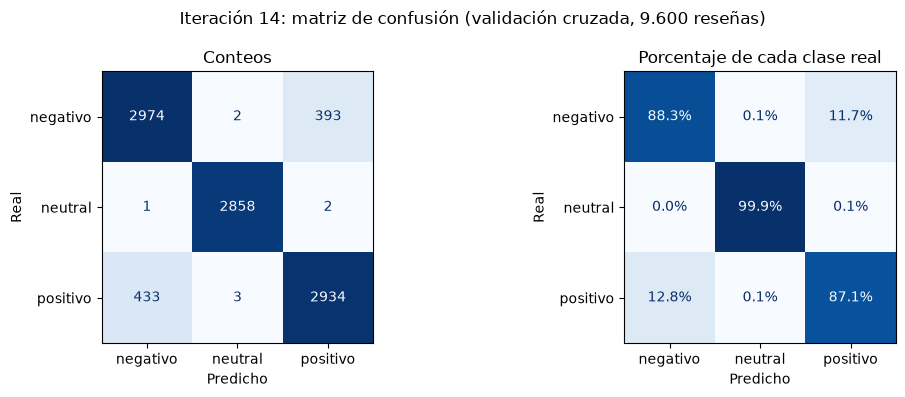

Errores totales: 834 | entre positivo y negativo: 826 (99.0% de los errores)


In [28]:
# 8.1 Matriz de confusión y métricas por clase del modelo final (iteración 14, predicciones de validación cruzada)
print(classification_report(y_ent, pred_iter14, labels=LABELS, digits=3))

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_ent, pred_iter14, labels=LABELS, cmap="Blues", colorbar=False, ax=ejes[0])
ejes[0].set_title("Conteos")
ConfusionMatrixDisplay.from_predictions(y_ent, pred_iter14, labels=LABELS, cmap="Blues", colorbar=False,
                                        normalize="true", values_format=".1%", ax=ejes[1])
ejes[1].set_title("Porcentaje de cada clase real")
for eje in ejes:
    eje.set_xlabel("Predicho"); eje.set_ylabel("Real")
plt.suptitle("Iteración 14: matriz de confusión (validación cruzada, 9.600 reseñas)")
plt.tight_layout(); plt.show()

errores = pred_iter14.values != y_ent.values
confusion_pos_neg = ((y_ent.values == "positivo") & (pred_iter14.values == "negativo")).sum() + \
                    ((y_ent.values == "negativo") & (pred_iter14.values == "positivo")).sum()
print(f"Errores totales: {errores.sum()} | entre positivo y negativo: {confusion_pos_neg} "
      f"({confusion_pos_neg / errores.sum():.1%} de los errores)")

**Cómo se lee**
- **`neutral` está resuelta:** precisión 0,998, recall 0,999 y F1 0,999. De 2.861 reseñas neutrales solo 3 se clasificaron mal, y solo 5 reseñas polares se confundieron con neutral. Las reseñas neutrales no tienen opiniones, solo logística y descripción, y cualquier modelo de esta sección las reconoce.
- **Casi todo el error está entre `positivo` y `negativo`:** 826 de los 834 errores (99,0 %) son una reseña positiva clasificada como negativa (433) o al revés (393). Las dos clases quedan con F1 de 0,876 y 0,878.
- **Hay una leve inclinación hacia `negativo`:** el modelo falla un poco más con las positivas (recall 0,871) que con las negativas (0,883). Es una diferencia pequeña, pero aparece igual en las iteraciones anteriores.
- **Comparado con la bolsa de palabras de la sección 5:** allí `neutral` ya estaba casi resuelta, pero positivo y negativo se confundían en cerca de un tercio de los casos. Ahora se confunden en el 12 %. Todo lo que se ganó desde la sección 6 vino de separar mejor esas dos clases.

### 8.2 Qué aprendió el modelo
El stack de 29 modelos no tiene pesos que se puedan leer directamente, pero su primer modelo base sí: las tres vistas de la iteración 08 (texto completo, lo que sigue al último conector y última oración) con una regresión logística. Se muestran los términos con mayor coeficiente hacia cada clase en dos de las vistas, y el peso de algunas palabras en cada una.

In [29]:
# 8.2 Qué aprendió el modelo: pesos de la regresión logística de las tres vistas (el modelo de la iteración 08,
# que es el primer modelo base del stack). Se entrena solo con las 9.600 reseñas de entrenamiento.
modelo_vistas = tres_vistas().fit(X_ent, y_ent)
union = modelo_vistas.named_steps["vistas"]
logistica = modelo_vistas.named_steps["clf"]

nombres, inicio = {}, 0
for nombre_vista, pipeline_vista in union.transformer_list:
    vocabulario = pipeline_vista.named_steps["tfidf"].get_feature_names_out()
    nombres[nombre_vista] = (inicio, vocabulario)
    inicio += len(vocabulario)


def terminos_con_mas_peso(nombre_vista, clase, n=12):
    """Los n términos de una vista con mayor coeficiente hacia una clase."""
    desde, vocabulario = nombres[nombre_vista]
    pesos = logistica.coef_[list(logistica.classes_).index(clase), desde:desde + len(vocabulario)]
    orden = np.argsort(-pesos)[:n]
    return [f"{vocabulario[i]} ({pesos[i]:.1f})" for i in orden]


for nombre_vista in ["completo", "ultima"]:
    print(f"\n=== Vista: {nombre_vista} ===")
    display(pd.DataFrame({clase: terminos_con_mas_peso(nombre_vista, clase) for clase in LABELS}))

# La misma palabra pesa distinto según dónde aparece
print("\nPeso hacia 'positivo' de la misma palabra en cada vista:")
filas = []
for palabra in ["excelente", "feliz", "encanto", "decepciono", "pesimo", "regalado"]:
    fila = {"palabra": palabra}
    for nombre_vista, (desde, vocabulario) in nombres.items():
        posicion = np.where(vocabulario == palabra)[0]
        fila[nombre_vista] = round(float(logistica.coef_[list(logistica.classes_).index("positivo"),
                                                         desde + posicion[0]]), 2) if len(posicion) else None
    filas.append(fila)
display(pd.DataFrame(filas))


=== Vista: completo ===


,negativo,neutral,positivo
0,defraudo (3.0),viene (2.4),estrellas (2.8)
1,decepciono (2.7),trae (2.4),encima (2.5)
2,verdad (2.3),color (2.4),supero (2.5)
3,error (2.3),tamanos (2.3),feliz (2.3)
4,muy (2.2),paquete (2.1),buscando (2.3)
5,vale (2.2),kilo (2.1),alegra (2.2)
6,estrella (2.2),unidades (2.0),verdad (2.2)
7,cuesta (2.1),puerto (1.9),pena (2.2)
8,debajo (2.0),siempre (1.9),calidad (2.1)
9,molesto (2.0),voltios (1.8),me (2.0)



=== Vista: ultima ===


,negativo,neutral,positivo
0,mal (4.0),por (1.8),buena (2.9)
1,poco (2.8),contar (1.2),resistente (2.6)
2,pobre (2.7),nada (1.1),espectacular (2.5)
3,debil (2.6),he (1.1),funcional (2.4)
4,inconsistente (2.6),viene (1.1),impecable (2.4)
5,deficiente (2.5),solo (1.0),decente (2.4)
6,endeble (2.5),trae (1.0),sobresaliente (2.4)
7,pesima (2.4),pesa (1.0),formidable (2.4)
8,decepcionante (2.4),puedo (0.9),potente (2.4)
9,ruidosa (2.3),comentar (0.8),solido (2.2)



Peso hacia 'positivo' de la misma palabra en cada vista:


,palabra,completo,tras_conector,ultima
0,excelente,0.41,2.31,2.20
1,feliz,2.31,0.60,1.94
2,encanto,1.86,0.34,0.47
3,decepciono,-1.37,-0.38,-0.29
4,pesimo,-0.28,-1.43,-1.38
5,regalado,-1.43,0.21,-0.32


**Cómo se lee**
- **Los términos de `neutral` son los mismos que encontró el EDA:** "viene", "trae", "color", "tamaños", "paquete", "unidades", "voltios", "usb", "sellado". Son palabras de descripción y logística, justo las que en la sección 3 aparecían mucho más en las neutrales.
- **Las dos vistas aprendieron cosas distintas, y eso confirma lo que se encontró en la iteración 14:**
  - En la **última oración** dominan **adjetivos**: "mal", "pobre", "débil", "deficiente", "pésima" hacia negativo; "buena", "resistente", "espectacular", "impecable", "sólido" hacia positivo.
  - En el **texto completo** dominan **frases hechas**: "defraudó" (todas mis expectativas), "decepcionó" (de principio a fin), "no vale lo que cuesta", "ni regalado", "una estrella" hacia negativo; "superó", "justo lo que estaba buscando", "me alegra haber elegido", "vale la pena", "cinco estrellas" hacia positivo.
- **La misma palabra pesa distinto según dónde está:**
  - "excelente" casi no cuenta en el texto completo (0,41) pero pesa mucho al final (2,31 tras el conector, 2,20 en la última oración). "pésimo" igual, hacia negativo (−0,28 frente a −1,43 y −1,38). Con los adjetivos **manda la posición**: la última opinión decide.
  - "feliz", "encantó", "decepcionó" y "regalado" pesan más en el texto completo que al final. Son parte de frases hechas, y con ellas la posición no decide igual. Eso es lo que hace que las reseñas con dos frases hechas opuestas sean una moneda al aire.
- **Coincidencias con el EDA:** "verdad" aparece hacia negativo y hacia positivo a la vez (en el EDA estaba en ~40 % de las polares y solo en el 2 % de las neutrales: marca que hay opinión, no cuál), y "me" pesa hacia positivo (en el EDA, 72-74 % en las polares frente a 53 % en las neutrales).

### 8.3 Lectura de errores
Cada reseña de entrenamiento se clasifica según su estructura, mirando solo el texto: si cierra con una frase indecisa, si tiene un conector aditivo ("por otro lado", "por cierto", "además"), si tiene un conector contrastivo ("aun así", "pero", "al final") o si no tiene conector. Para cada tipo se cuentan los errores del modelo final y se leen 30 reseñas mal clasificadas.

In [30]:
# 8.3 Lectura de errores: tipos de reseña y 30 errores para leer
ADITIVOS = re.compile(r"\b(por otro lado|por cierto|de paso|ademas)\b")


def tipo_de_resena(texto):
    """Clasifica la reseña según su estructura (solo mira el texto, nunca la etiqueta ni la predicción)."""
    t = corregir_texto(texto)
    if CIERRE.search(t):
        return "1. cierre indeciso"
    if ADITIVOS.search(t):
        return "2. conector aditivo (por otro lado, por cierto...)"
    if PATRON_CONECTOR.search(t):
        return "3. conector contrastivo (aun así, pero, al final...)"
    return "4. sin conector"


tipos = X_ent.map(tipo_de_resena)
resumen = (pd.DataFrame({"tipo": tipos, "error": errores})
           .groupby("tipo")["error"].agg(reseñas="size", errores="sum"))
resumen["acierto"] = (1 - resumen["errores"] / resumen["reseñas"]).round(3)
resumen["% de los errores"] = (100 * resumen["errores"] / resumen["errores"].sum()).round(1)
display(resumen)

# 30 errores para leer: 8 de cada uno de los tres primeros tipos y 6 sin conector
pd.set_option("display.max_colwidth", None)
cuantos = {"1. cierre indeciso": 8, "2. conector aditivo (por otro lado, por cierto...)": 8,
           "3. conector contrastivo (aun así, pero, al final...)": 8, "4. sin conector": 6}
for tipo, n in cuantos.items():
    candidatos = X_ent[errores & (tipos == tipo).values]
    print(f"\n==================== {tipo}: {len(candidatos)} errores (se muestran {min(n, len(candidatos))}) ====================")
    for idx in candidatos.sample(min(n, len(candidatos)), random_state=SEED).index:
        print(f"\n[real: {y_ent[idx]} | predicho: {pred_iter14[idx]}]")
        print(X_ent[idx])

,reseñas,errores,acierto,% de los errores
tipo,,,,
1. cierre indeciso,1193,542,0.546,65.0
"2. conector aditivo (por otro lado, por cierto...)",1411,130,0.908,15.6
"3. conector contrastivo (aun así, pero, al final...)",3893,94,0.976,11.3
4. sin conector,3103,68,0.978,8.2



==================== 1. cierre indeciso: 542 errores (se muestran 8) ====================

[real: positivo | predicho: negativo]
Lo compré hace un par de meses para usarlo en casa, llegó en unos cinco días. Llevando un tiempo con él, me decepcionó la comodidad de principio a fin. Por otro lado, la portabilidad superó todas mis expectativas. Lo dejé en la sala y de ahí no se mueve. Hay de todo, como se ve.

[real: negativo | predicho: positivo]
La instalación me pareció facilísima, la hice yo solo en un rato una tarde después del trabajo. El detalle es que el botón de encendido no me funcionó bien ni un solo día desde que llegó, que lo compré a comienzos de mes. Le pondría cinco estrellas a la instalación. De paso, no paré de tener problemas con el botón de encendido. Ahí lo dejo, cada quien sacará sus conclusiones.

[real: positivo | predicho: negativo]
Desde hace meses, lo pedí en oferta. Me arrepiento de haber elegido la calidad. Además, estoy feliz con la correa. No sabría bien qué

**Errores por tipo de reseña (iteración 14, validación cruzada)**

| Tipo de reseña | Reseñas | Errores | Acierto | % de los errores |
|---|---|---|---|---|
| 1. Cierre indeciso | 1.193 | 542 | 54,6 % | 65,0 % |
| 2. Conector aditivo ("por otro lado", "por cierto", "además") | 1.411 | 130 | 90,8 % | 15,6 % |
| 3. Conector contrastivo ("aun así", "pero", "al final") | 3.893 | 94 | 97,6 % | 11,3 % |
| 4. Sin conector | 3.103 | 68 | 97,8 % | 8,2 % |

**Tipos de error encontrados** (lectura de las 30 reseñas mal clasificadas que imprime la celda)

| Tipo de error | Ejemplo | Cambio propuesto |
|---|---|---|
| **Dos frases hechas de polaridad opuesta** (más de 25 de los 30 errores, en los cuatro tipos de reseña) | *"No volvería a comprar el cargador ni regalado. Eso sí, cada peso que pagué por el material valió la pena."* (real: positivo) · *"Me arrepiento de haber elegido la velocidad. Lo único es que el material me sorprendió para bien."* (real: negativo) | **Ninguno posible.** Con dos frases hechas opuestas la etiqueta no depende del orden ni del conector: es casi una moneda al aire (iteración 14). Modelos entrenados solo con estas reseñas no pasan de 0,48-0,52 (análisis en `experimentos/`). |
| **Cierre indeciso no detectado** por un error de tipeo o una frase nueva | *"Queda a criteiro de cada uno."* · *"Aún no sé si lo volvería a pedir, la verdad ando entre la espada y la pared con esto."* · *"Ahí queda mi valoración."* | Que la detección del cierre tolere errores de tipeo (por ejemplo, con n-gramas de caracteres) y ampliar la lista. Efecto esperado mínimo: esas reseñas siguen siendo de la zona de moneda al aire. |
| **Error de tipeo en una palabra clave** | *"No tengo ni una sola queja de la relación calidad-precio, peero me decepcionó la cámara de principio a fin."* · *"el ensamblaje terminó siendo buenisiimo"* | Los n-gramas de caracteres de las iteraciones 10 a 14 ya cubren parte de esto. Un corrector ortográfico aprendido del vocabulario se probó en la iteración 14 y su efecto fue mínimo. |
| **Conector que no está en la lista** | *"Lo que sí es que el control remoto no vale lo que cuesta."* · *"El detalle es que el botón de encendido no me funcionó bien ni un solo día."* | Agregar "lo que sí es que" y "el detalle es que" a `CONECTORES`. Son pocos casos, y casi todos también tienen dos frases hechas opuestas. |

**Conclusión del análisis de errores**
- **Más del 90 % del error que queda no se puede corregir con el texto.** El 65 % de los errores está en las reseñas con cierre indeciso, donde el modelo acierta el 54,6 %, poco más que al azar. La mayoría del resto, como muestra la lectura, son reseñas sin frase de cierre pero con dos frases hechas opuestas: el mismo fenómeno.
- **Fuera de esa zona el modelo acierta casi todo:** 97,6-97,8 % en las reseñas con conector contrastivo o sin conector. Los errores corregibles (tipeos, frases de cierre o conectores que faltan en las listas) son unas decenas de 9.600.
- **Por eso no se volvió a las secciones 5 a 7 para otra iteración:** aun corrigiendo todos los errores evitables, la mejora posible es de menos de medio punto, por debajo del ruido del score público de Kaggle (±0,7 puntos con ~900 reseñas). El modelo final queda en la iteración 14.

## 9. Modelo final
El modelo final es la **iteración 14**: la mejor en validación cruzada y la del mejor score público del grupo en Kaggle (0,90777).

### 9.1 Evaluación en la prueba (una sola vez)
Se entrena la iteración 14 con las 9.600 reseñas de entrenamiento y se mide en las 2.400 que se apartaron en 4.1. Es la única vez que este notebook usa la prueba, y ninguna decisión se tomó con ella: el modelo se eligió con validación cruzada (sección 7). En los notebooks de `notebooks_iteraciones/` la prueba también se miró al final de las iteraciones 10, 12, 13 y 14, siempre solo para reportar.

Entrenado y evaluado en 1.8 minutos

Accuracy en validación cruzada: 0.9131
Accuracy en la prueba:          0.9137  (error estándar ±0.6 puntos)

              precision    recall  f1-score   support

    negativo      0.871     0.886     0.878       843
     neutral      1.000     0.999     0.999       715
    positivo      0.884     0.869     0.877       842

    accuracy                          0.914      2400
   macro avg      0.918     0.918     0.918      2400
weighted avg      0.914     0.914     0.914      2400

Errores en la prueba: 207 de 2400
  con cierre indeciso:  142 de   317  (acierto 0.552)
  resto:                 65 de  2083  (acierto 0.969)


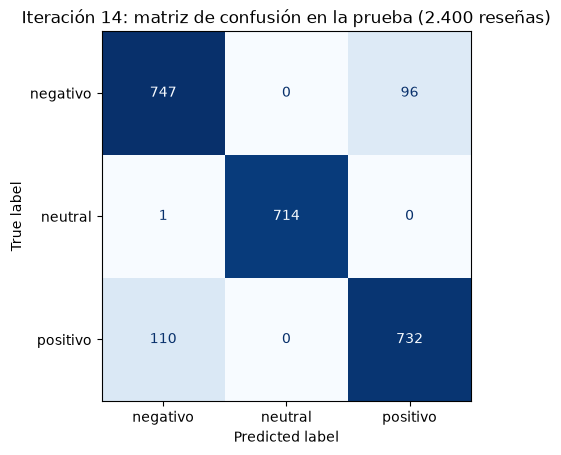

In [31]:
# 9.1 Evaluación en la prueba (una sola vez): iteración 14 entrenada con las 9.600 reseñas de entrenamiento
inicio = time.perf_counter()
modelo_prueba = clone(iter14).set_params(n_jobs=-1).fit(X_ent, y_ent)
pred_prueba = modelo_prueba.predict(X_prueba)
print(f"Entrenado y evaluado en {(time.perf_counter() - inicio) / 60:.1f} minutos\n")

acc_prueba = accuracy_score(y_prueba, pred_prueba)
acc_cv = tabla("7").set_index("experimento").loc["iter14: bases también sin reseñas indecisas", "accuracy"]
error_estandar = np.sqrt(acc_prueba * (1 - acc_prueba) / len(X_prueba))
print(f"Accuracy en validación cruzada: {acc_cv:.4f}")
print(f"Accuracy en la prueba:          {acc_prueba:.4f}  (error estándar ±{error_estandar * 100:.1f} puntos)\n")
print(classification_report(y_prueba, pred_prueba, labels=LABELS, digits=3))

indecisas_prueba = ~sin_cierre(X_prueba)
error_prueba = pred_prueba != y_prueba.values
print(f"Errores en la prueba: {error_prueba.sum()} de {len(error_prueba)}")
print(f"  con cierre indeciso: {error_prueba[indecisas_prueba].sum():>4} de {indecisas_prueba.sum():>5}"
      f"  (acierto {1 - error_prueba[indecisas_prueba].mean():.3f})")
print(f"  resto:               {error_prueba[~indecisas_prueba].sum():>4} de {(~indecisas_prueba).sum():>5}"
      f"  (acierto {1 - error_prueba[~indecisas_prueba].mean():.3f})")

ConfusionMatrixDisplay.from_predictions(y_prueba, pred_prueba, labels=LABELS, cmap="Blues", colorbar=False)
plt.title("Iteración 14: matriz de confusión en la prueba (2.400 reseñas)"); plt.show()

**Resultado**

| | Validación cruzada (9.600) | Prueba (2.400) |
|---|---|---|
| Accuracy | 0,9131 | **0,9137** (error estándar ±0,6 puntos) |
| F1 macro | 0,9174 | 0,918 |
| Acierto con cierre indeciso | 54,6 % | 55,2 % (142 errores de 317) |
| Acierto en el resto | 96,5 % | 96,9 % (65 errores de 2.083) |

- **La prueba confirma la validación cruzada:** 0,9137 frente a 0,9131, una diferencia de 0,06 puntos, muy por debajo de su error estándar (±0,6). En el computador donde se generaron los envíos, la prueba de esta misma iteración dio 0,9150, también dentro de ese margen.
- **Lo esperable habría sido que la prueba diera un poco menos.** Al elegir el mejor de muchos modelos con la validación cruzada, la cifra del elegido queda un poco optimista: parte de su ventaja puede ser suerte de esos pliegues, y en datos nuevos esa suerte no se repite. Aquí no se nota porque las diferencias entre los últimos candidatos eran pequeñas y la iteración 14 se eligió por un criterio más robusto (errores fuera de la zona de moneda al aire en cuatro particiones) y no por el máximo de una sola validación.
- **El patrón de errores es el mismo:** `neutral` sale casi perfecta (1 error de 715), todos los demás errores son confusiones entre `positivo` y `negativo` (96 + 110), y se concentran en las reseñas con cierre indeciso, donde el modelo acierta poco más que una moneda.

### 9.2 Modelo entregado, envío y guardado
El enunciado pide entregar **el modelo del envío con mejor score público**: el de la iteración 14 (0,90777). Por eso aquí **no se reentrena**. Se carga el mismo `.joblib` que generó ese envío (`models/iteraciones/iter14_bases_sin_indecisas.joblib`), se predice `eval.csv`, se valida el formato y se comprueba que las predicciones coinciden con el archivo subido a Kaggle.

¿Por qué no reentrenar? La sección 7 mostró que reentrenar estos stacks en otro computador cambia algunas predicciones (en la iteración 10, 87 de 3.000), por diferencias numéricas entre sistemas operativos. Un modelo reentrenado aquí ya no sería exactamente el del envío. El modelo cargado, en cambio, tiene sus parámetros fijos.

Los dos entregables se guardan con los nombres del plan del proyecto: `submissions/sub_parte1_final.csv` y `models/parte1_final.joblib`.

In [32]:
# 9.2 Modelo final: el MISMO modelo que generó el envío de mejor score público (iteración 14, 0,90777)
import shutil

NOMBRE_ITER14 = "iter14_bases_sin_indecisas"
ruta_modelo_envio = MODEL_DIR / "iteraciones" / f"{NOMBRE_ITER14}.joblib"
ruta_csv_envio = ENVIOS_KAGGLE_DIR / f"{NOMBRE_ITER14}.csv"

inicio = time.perf_counter()
modelo_final = joblib.load(ruta_modelo_envio)
print(f"Modelo cargado: {type(modelo_final).__name__} con {len(modelo_final.estimators_)} modelos base "
      f"y metamodelo {type(modelo_final.final_estimator_).__name__}")

envio_final = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})
assert list(envio_final.columns) == ["id", "answer"]
assert len(envio_final) == 3000 and envio_final["id"].is_unique and set(envio_final["id"]) == set(muestra["id"])
assert envio_final["answer"].isin(LABELS).all()
print(f"Predicción de eval.csv en {(time.perf_counter() - inicio) / 60:.1f} minutos")

subido = pd.read_csv(ruta_csv_envio)
diferencias = int((envio_final["answer"].values != subido["answer"].values).sum())
print(f"Predicciones distintas al envío subido a Kaggle (0,90777): {diferencias} de 3000")
print("Predicciones por clase:", envio_final["answer"].value_counts().to_dict())

# Entregables con los nombres del plan del proyecto
envio_final.to_csv(SUB_DIR / "sub_parte1_final.csv", index=False)
shutil.copyfile(ruta_modelo_envio, MODEL_DIR / "parte1_final.joblib")
print(f"\nGuardados: {SUB_DIR / 'sub_parte1_final.csv'} y {MODEL_DIR / 'parte1_final.joblib'} "
      f"({(MODEL_DIR / 'parte1_final.joblib').stat().st_size / 1e6:.1f} MB)")

Modelo cargado: StackingClassifier con 29 modelos base y metamodelo HistGradientBoostingClassifier
Predicción de eval.csv en 0.2 minutos
Predicciones distintas al envío subido a Kaggle (0,90777): 0 de 3000
Predicciones por clase: {'positivo': 1121, 'negativo': 1055, 'neutral': 824}

Guardados: submissions\sub_parte1_final.csv y models\parte1_final.joblib (37.8 MB)


### 9.3 Prueba de replicabilidad
Se carga el modelo entregado (`models/parte1_final.joblib`) y se comprueba que sus predicciones sobre `eval.csv` son idénticas al archivo de envío guardado y al que se subió a Kaggle.

Para cargar el `.joblib` en una sesión nueva hay que ejecutar antes las celdas que definen las funciones y clases del pipeline (secciones 3, 6.1, 7.1, 7.2, 7.3, 7.4 y 7.5): `joblib` guarda el modelo entrenado, pero no el código de esas funciones. La forma más simple es ejecutar el notebook completo (**Restart → Run All**).

In [33]:
# 9.3 Prueba de replicabilidad: cargar el modelo entregado y comprobar que reproduce el envío
recargado = joblib.load(MODEL_DIR / "parte1_final.joblib")
pred_recargado = recargado.predict(eval_df["text"])

guardado = pd.read_csv(SUB_DIR / "sub_parte1_final.csv")
subido = pd.read_csv(ENVIOS_KAGGLE_DIR / "iter14_bases_sin_indecisas.csv")
print("Idéntico a submissions/sub_parte1_final.csv:", bool((pred_recargado == guardado["answer"].values).all()))
print("Predicciones distintas al envío subido a Kaggle:", int((pred_recargado != subido["answer"].values).sum()), "de 3000")

Idéntico a submissions/sub_parte1_final.csv: True
Predicciones distintas al envío subido a Kaggle: 0 de 3000


**Resultado de la replicabilidad**
- El modelo de la iteración 14, **generado en otro computador y otro sistema operativo** y cargado aquí desde su `.joblib`, predice `eval.csv` con **0 diferencias de 3.000** frente al envío que obtuvo 0,90777 en Kaggle.
- El modelo entregado (`models/parte1_final.joblib`, 37,8 MB), recargado, produce exactamente el archivo guardado `submissions/sub_parte1_final.csv`.

Con esto se cumplen los requisitos de la entrega: un solo modelo, el del mejor envío público del grupo, guardado con `joblib` y replicable a partir de este notebook y de su archivo. A Bloque Neón se suben `parte1.ipynb` y `models/parte1_final.joblib`.

## 10. Bitácora de envíos y conclusiones
Mínimo **5 envíos distintos** a Kaggle.

| # | Fecha | Modelo / cambio | Exactitud en validación cruzada | Score público Kaggle |
|---|-------|-----------------|---------------------------------|----------------------|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |

Línea base del curso en Kaggle: _TODO_

### Conclusiones finales _(TODO)_
- Mejor modelo y por qué: ...
- Qué aportó cada decisión (con números de la tabla de experimentos): ...
- Lo que este modelo no puede hacer (orden, negación, sinónimos, palabras nuevas) y por qué eso motiva la Parte 2: ...

## 11. Declaración de uso de IA generativa
El curso pide, para el proyecto, declarar el uso de IA generativa y anexar los prompts.

| Pregunta | Respuesta |
|---|---|
| ¿Qué herramienta se usó? (nombre y versión) | _TODO_ |
| ¿Para qué se usó? | _TODO_ |
| ¿Qué parte del trabajo resultó de ella? | _TODO_ |
| ¿Cómo se verificó lo que produjo? | _TODO_ |

Anexo de prompts: _TODO (archivo o enlace)_